# **🚴‍♀️ Проект спринта: Нелинейные модели против сочинской погоды**

Компания **BikeSochi**, оператор городского велопроката в Сочи, обратилась за помощью в улучшении системы прогнозирования почасового спроса на велосипеды.

До этого аналитики компании использовали простую линейную регрессию — одну из самых базовых моделей машинного обучения.

Однако её прогнозы часто ошибались:



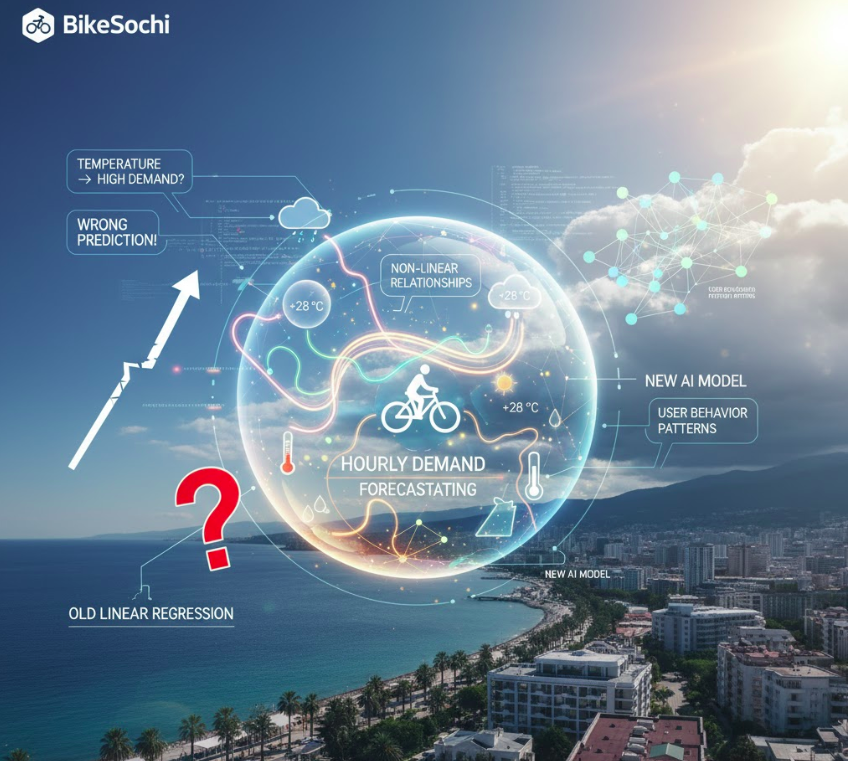

> «Модель видела, что температура выросла — и сразу предсказывала высокий спрос.
Но не понимала, что +28 °C под палящим солнцем и +28 °C после дождя — это две совсем разные ситуации.»

Погода в Сочи меняется быстро, и влияние факторов — нелинейное: температура, влажность, солнечная радиация, осадки влияют на поведение людей не по простым прямым зависимостям.



---



В рамках этого проекта вы выступаете в роли аналитиков компании **BikeSochi, которые должны предложить новую, более гибкую модель прогнозирования.**

**В этом проекте вы:**

1. Изучите предоставленную компанией baseline-модель (линейную регрессию);

2. Обучите новые модели — K-ближайших соседей (KNN) и решающее дерево (Decision Tree);

3. Проведёте подбор гиперпараметров с помощью библиотеки Optuna;

4. Сравните результаты всех подходов, выберете наилучший и аргументируете свой выбор.

Дополнительно: Реализуете собственный класс-трансформер и интегрируете его в пайплайн.


**К концу проекта у вас будет:**

— улучшенная модель прогноза почасового спроса на велосипеды в Сочи;

— отчёт с метриками и сравнением подходов;

— сохранённый пайплайн лучшей модели.



---



# **Часть 1: Базовая модель**

В этой части вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSochi до внедрения улучшенной версии.

Компания предоставила вам:

— `models/baseline_linear_regression_pipeline.joblib` — готовый обученный пайплайн (без исходного кода);

— краткое описание того, как он был устроен;

— тренировочную и тестовую выборки, которые можно использовать для оценки модели.

Это значит, что вам не нужно обучать эту модель заново — вы просто загружаете её и проверяете качество (например, на метриках RMSE, MAE, R²).

**Совет:**
1. Убедитесь, что у вас есть `models/baseline_linear_regression_pipeline.joblib`, `data/raw/ds_s14_train_data.csv` и `data/raw/ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки (X) и целевую переменную Rented Bike Count.

3. Загрузите `.joblib` файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R², эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

# **Часть 2: Улучшение модели — KNN и Decision Tree**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы сочинской погоды и поведение клиентов.

Вы будете экспериментировать с K-ближайшими соседями (KNN) и решающим деревом (Decision Tree), использовать подбор гиперпараметров с Optuna и внедрять кастомные трансформеры для новых признаков.

**Шаг 1: Изучение постановки задачи:**

Проведите EDA (Exploratory Data Analysis):
1. Посмотрите на распределение целевой переменной Rented Bike Count. Есть ли выбросы или сильные сезонные колебания?
2. Постройте графики зависимости спроса от температуры, осадков, солнечной радиации.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Проверьте корреляции между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять. Начните с базовых графиков и описательной статистики.



---



**Шаг 2: Разделение данных на тренировочную и валидационную выборки**

> У вас есть доступ к тренировочной и тестовой выборкам.

Тестовый набор используется для финальной оценки модели после тренировки и подбора гиперпараметров.

Вы тренируетесь на тренировочных данных и оцениваете качество через валидацию.

---



**Шаг 3: Обучение новых моделей**

> Теперь пора «проверить, насколько далеко уедут модели» — KNN и Decision Tree могут уловить нелинейные зависимости, недоступные линейной регрессии.

Что нужно сделать:
1. Подготовьте пайплайн для каждой модели:
    * Предобработка данных.
    * Модель (KNN или Decision Tree).
4. Настройте базовые параметры моделей (например, n_neighbors для KNN, max_depth для дерева).

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров делаем на следующем шаге.

---



**Шаг 4: Подбор гиперпараметров с Optuna**

> Компания хочет точную модель. Optuna поможет найти лучшие параметры для KNN и дерева, чтобы снизить ошибки прогноза.

Что нужно сделать:
1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь экспериментировать с небольшими диапазонами сначала, а потом расширять, если модель «не уловила» зависимости.

---



**Шаг 5: Кросс-валидация новых моделей**

Что нужно сделать:
1. Проведите кросс-валидацию для KNN и Decision Tree с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (bar plot, box plot), чтобы увидеть разброс метрик и стабильность моделей.


---



**Шаг 6: Составление отчёта по моделям**

Что нужно сделать:
1. Составьте таблицу с метриками: baseline, KNN, Decision Tree.
2. Добавьте визуализацию, если необходимо: bar plot или box plot по RMSE/MAE.

Подготовьте выводы:
1. Какая модель лучше справляется с прогнозом?
2. Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте: «Эта модель лучше реагирует на дождь», «Температура и влажность сильно влияют на спрос в пиковые часы».

---



**Шаг 7: Сохранение модели и отчёта**

Что нужно сделать:
1. Выберите финальную, наилучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько она прогнозирует реальные данные.
2. Подготовьте ноутбук с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг: почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче это помогает коллегам и руководству понимать решения и доверять модели.

---



**Опционально: Реализация кастомного трансформера**

> Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию.
Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

Что нужно сделать:
1. Реализуйте класс с методами fit и transform.
2. Вставьте его в пайплайн перед моделью.
3. Проверьте, что трансформер корректно работает с тренировочными данными.

**Совет:**
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---



# **Авторское решение**

<a id="author-solution"></a>
# Авторское решение: прогнозирование спроса на велопрокат BikeSouth

Для проката велосипедов ошибка прогноза - это не абстрактный скоринг. Завышенный спрос ведет к лишней подаче велосипедов, перегруженным точкам и неэффективным сменам персонала; заниженный спрос - к пустым стойкам в часы пика, потерянным поездкам и ухудшению клиентского опыта. Поэтому модель здесь нужна как инструмент операционного планирования: заранее понять, где и когда спрос будет высоким, а где ресурсы можно держать экономнее.

**Цель:** выбрать модель, которая лучше предоставленной линейной регрессии прогнозирует почасовой спрос `Rented Bike Count` и дает реалистичные неотрицательные прогнозы, пригодные для планирования парка и смен.

**Основная метрика:** `RMSE`, потому что крупные промахи в пиковые часы для проката особенно дороги. Дополнительно считаю `MAE` и `R2`: `MAE` показывает типичную ошибку в велосипедах в час, а `R2` помогает понять, насколько модель объясняет изменчивость спроса относительно простого среднего.

**Ключевое ограничение:** `ds_s14_test_data.csv` не используется для подбора гиперпараметров и выбора модели. Новые модели выбираются только по 5-fold CV на `ds_s14_train_data.csv`; test применяется один раз в конце.


<a id="navigation"></a>
## Навигация по исследованию

1. [Методологическая рамка](#methodology)
2. [Этап 1. Среда, константы и пути](#stage-1)
3. [Этап 2. Загрузка данных и контракт схемы](#stage-2)
4. [Этап 3. Baseline компании](#stage-3)
5. [Этап 4. Первичный аудит и EDA](#stage-4)
6. [Этап 5. Pipeline и feature engineering](#stage-5)
7. [Этап 6. Optuna и 5-fold CV](#stage-6)
8. [Этап 7. Финальная проверка на test](#stage-7)
9. [Этап 8. Интерпретация и артефакты](#stage-8)
10. [Финальные выводы](#final-conclusions)


<a id="methodology"></a>
## Методологическая рамка

В этой задаче легко получить внешне хороший результат и при этом испортить честность оценки. Для бизнеса это опасно: модель с завышенной метрикой быстро приведет к неверному распределению велосипедов и доверие к аналитике будет потеряно после первых пиковых дней. Поэтому заранее фиксирую правила эксперимента.

- Все обучаемые преобразования (`imputer`, `scaler`, `encoder`, модель) живут внутри `Pipeline`.
- Финальная test-выборка не участвует в Optuna, выборе модели или выборе признаков.
- Для новых моделей используется единая `KFold(n_splits=5, shuffle=True, random_state=42)`.
- В Optuna минимизируется RMSE. Так как `sklearn` для regression scoring возвращает отрицательные значения, в objective используется `-scores["test_rmse"].mean()`.
- Baseline компании оценивается отдельно как предоставленная модель. Его test-метрики нужны для итогового сравнения, но не для настройки новых моделей.
- Графики используются не декоративно: каждый блок EDA должен дать решение для предобработки, признаков или интерпретации.
- Финальная рекомендация должна отвечать на операционные вопросы: насколько ошибка меньше baseline, исчезли ли невозможные отрицательные прогнозы, какие факторы мониторить и почему модель нельзя запускать без проверки на свежем периоде.


<a id="stage-1"></a>
## Этап 1. Среда, константы и пути

Сначала фиксирую импорты, настройки отображения, seed и рабочие пути. Это защищает ноутбук от скрытого состояния: его можно перезапустить сверху вниз и получить те же фолды, те же trials Optuna и те же метрики.


In [1]:
from __future__ import annotations

import hashlib
import importlib
import json
import platform
import sys
import time
import warnings
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import Markdown, display
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
CV_SPLITS = 5
N_TRIALS_KNN = 35
N_TRIALS_TREE = 45
TARGET_ORIGINAL = "Rented Bike Count"
TARGET = "rented_bike_count"

def find_project_root(start: Optional[Path] = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        has_project_files = all(
            [
                (candidate / "data" / "raw" / "ds_s14_train_data.csv").exists(),
                (candidate / "data" / "raw" / "ds_s14_test_data.csv").exists(),
                (candidate / "models" / "baseline_linear_regression_pipeline.joblib").exists(),
            ]
        )
        if has_project_files:
            return candidate
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
COMPONENT_MODULE_NAME = "bike_demand_pipeline_components"
COMPONENT_MODULE_PATH = PROJECT_ROOT / f"{COMPONENT_MODULE_NAME}.py"
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

versions = pd.DataFrame(
    [
        {"package": "python", "version": platform.python_version()},
        {"package": "pandas", "version": pd.__version__},
        {"package": "numpy", "version": np.__version__},
        {"package": "scikit-learn", "version": sklearn.__version__},
        {"package": "optuna", "version": optuna.__version__},
        {"package": "joblib", "version": joblib.__version__},
    ]
)
display(versions)


D:\DS\13\ml-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,package,version
0,python,3.11.9
1,pandas,3.0.2
2,numpy,2.4.3
3,scikit-learn,1.6.1
4,optuna,4.9.0
5,joblib,1.5.3


**Подвывод по этапу 1:** окружение зафиксировано. Особенно важна версия `scikit-learn`: предоставленный `baseline_linear_regression_pipeline.joblib` корректно загружается на `1.6.1`, поэтому эта версия закреплена в `requirements.txt`.


<a id="stage-2"></a>
## Этап 2. Загрузка данных и контракт схемы

CSV-файлы приходят с человекочитаемыми названиями колонок, а предоставленный baseline pipeline ожидает `snake_case`. Поэтому сначала создаю единую функцию нормализации схемы. Это снижает риск, что baseline и новые модели будут обучаться на разных представлениях одних и тех же данных.


In [2]:
COLUMN_RENAME = {
    "Temperature": "temperature",
    "Humidity(%)": "humidity",
    "Wind speed (m/s)": "wind_speed_ms",
    "Visibility (10m)": "visibility_10m",
    "Dew point temperature": "dew_point_temperature",
    "Solar Radiation (MJ/m2)": "solar_radiation_mjm2",
    "Rainfall(mm)": "rainfallmm",
    "Snowfall (cm)": "snowfall_cm",
    "Seasons": "seasons",
    "Holiday": "holiday",
    "Functioning Day": "functioning_day",
    "Time_Period_Evening": "time_period_evening",
    "Time_Period_Late Evening": "time_period_late_evening",
    "Time_Period_Morning": "time_period_morning",
    "Time_Period_Night": "time_period_night",
    TARGET_ORIGINAL: TARGET,
}

BASE_NUMERIC_FEATURES = [
    "temperature",
    "humidity",
    "wind_speed_ms",
    "visibility_10m",
    "dew_point_temperature",
    "solar_radiation_mjm2",
    "rainfallmm",
    "snowfall_cm",
]
CATEGORICAL_FEATURES = ["seasons", "holiday", "functioning_day"]
TIME_FEATURES = [
    "time_period_evening",
    "time_period_late_evening",
    "time_period_morning",
    "time_period_night",
]
BASE_FEATURES = BASE_NUMERIC_FEATURES + CATEGORICAL_FEATURES + TIME_FEATURES

FEATURE_DESCRIPTIONS_RU = {
    "temperature": "температура воздуха",
    "humidity": "влажность воздуха",
    "wind_speed_ms": "скорость ветра",
    "visibility_10m": "видимость",
    "dew_point_temperature": "температура точки росы",
    "solar_radiation_mjm2": "солнечная радиация",
    "rainfallmm": "количество осадков, дождь",
    "snowfall_cm": "количество снега",
    "seasons_Spring": "весенний сезон",
    "seasons_Summer": "летний сезон",
    "seasons_Winter": "зимний сезон",
    "holiday_No Holiday": "не праздничный день",
    "functioning_day_Yes": "прокат работает",
    "time_period_evening": "вечерний период",
    "time_period_late_evening": "поздний вечер",
    "time_period_morning": "утренний период",
    "time_period_night": "ночной период",
    "time_period_daytime": "дневной период",
    "rainfall_flag": "наличие дождя",
    "snowfall_flag": "наличие снега",
    "dew_point_gap": "разница температуры и точки росы",
    "comfort_temperature": "комфортный диапазон температуры",
    "low_visibility_flag": "низкая видимость",
    "temperature_x_humidity": "взаимодействие температуры и влажности",
    "temperature_x_solar": "взаимодействие температуры и солнечной радиации",
}

PARAMETER_DESCRIPTIONS_RU = {
    "n_neighbors": "число соседей",
    "weights": "веса соседей",
    "p": "метрика Минковского",
    "leaf_size": "размер листа поиска",
    "max_depth": "максимальная глубина",
    "min_samples_split": "минимум объектов для split",
    "min_samples_leaf": "минимум объектов в листе",
    "max_features": "число признаков для split",
    "ccp_alpha": "сила pruning",
    "random_state": "seed",
    "strategy": "стратегия dummy",
}


def feature_label_for_reader(feature: str) -> tuple[str, str, str]:
    technical = feature.replace("num__", "").replace("cat__", "")
    description = FEATURE_DESCRIPTIONS_RU.get(technical, technical.replace("_", " "))
    plot_label = f"{technical}\n{description}" if description != technical else technical
    return technical, description, plot_label


def short_params_for_plot(model_name: str, params: Dict[str, Any]) -> str:
    if not params:
        return "strategy=mean (среднее)"
    if model_name == "decision_tree_optuna":
        keys = ["max_depth", "min_samples_leaf", "min_samples_split"]
    elif model_name == "knn_optuna":
        keys = ["n_neighbors", "weights", "p"]
    else:
        keys = list(params)[:3]
    parts = []
    for key in keys:
        if key in params:
            parts.append(f"{key}={params[key]} ({PARAMETER_DESCRIPTIONS_RU.get(key, key)})")
    return "\n".join(parts)


def add_bar_labels(ax: plt.Axes, fmt: str) -> None:
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)


def read_csv_with_fallback(filename: str) -> pd.DataFrame:
    candidates = [DATA_DIR / filename, Path("/datasets") / filename]
    for candidate in candidates:
        if candidate.exists():
            return pd.read_csv(candidate)
    raise FileNotFoundError(f"Could not find {filename} in: {candidates}")


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    normalized = df.rename(columns=COLUMN_RENAME).copy()
    expected = set(COLUMN_RENAME.values())
    missing = sorted(expected - set(normalized.columns))
    if missing:
        raise ValueError(f"Missing expected columns after normalization: {missing}")
    return normalized[list(COLUMN_RENAME.values())]


train_raw = read_csv_with_fallback("ds_s14_train_data.csv")
test_raw = read_csv_with_fallback("ds_s14_test_data.csv")
train = normalize_columns(train_raw)
test = normalize_columns(test_raw)

X_train = train.drop(columns=TARGET)
y_train = train[TARGET]
X_test = test.drop(columns=TARGET)
y_test = test[TARGET]

data_overview = pd.DataFrame(
    [
        {"dataset": "train", "rows": train.shape[0], "columns": train.shape[1]},
        {"dataset": "test", "rows": test.shape[0], "columns": test.shape[1]},
    ]
)
display(data_overview)
display(train.head())

raw_feature_set = set(BASE_FEATURES)
feature_dictionary = pd.DataFrame(
    [
        {
            "technical_name": technical_name,
            "description_ru": description,
            "role": "исходный признак" if technical_name in raw_feature_set else "инженерный или encoded-признак",
        }
        for technical_name, description in FEATURE_DESCRIPTIONS_RU.items()
    ]
)
display(feature_dictionary)

assert train.shape == (7008, 16), "Unexpected train shape"
assert test.shape == (1752, 16), "Unexpected test shape"
assert list(train.columns) == list(test.columns), "Train/test schemas differ"
assert TARGET in train.columns and TARGET in test.columns


,dataset,rows,columns
0,train,7008,16
1,test,1752,16


,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,seasons,holiday,functioning_day,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,rented_bike_count
0,20.3000,35.0000,2.4000,"2,000.0000",4.3000,0.4600,0.0000,0.0000,Autumn,Holiday,Yes,True,False,False,False,1237
1,25.4000,55.0000,3.2000,"2,000.0000",15.6000,0.1500,0.0000,0.0000,Autumn,No Holiday,Yes,True,False,False,False,2468
2,-6.9000,39.0000,1.6000,"2,000.0000",-18.5000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,True,False,False,186
3,-5.2000,37.0000,2.2000,"2,000.0000",-17.6000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes,False,False,False,True,254
4,23.4000,34.0000,2.1000,"2,000.0000",6.6000,2.8400,0.0000,0.0000,Autumn,No Holiday,Yes,False,False,False,False,1686


,technical_name,description_ru,role
0,temperature,температура воздуха,исходный признак
1,humidity,влажность воздуха,исходный признак
2,wind_speed_ms,скорость ветра,исходный признак
3,visibility_10m,видимость,исходный признак
4,dew_point_temperature,температура точки росы,исходный признак
5,solar_radiation_mjm2,солнечная радиация,исходный признак
6,rainfallmm,"количество осадков, дождь",исходный признак
7,snowfall_cm,количество снега,исходный признак
8,seasons_Spring,весенний сезон,инженерный или encoded-признак
9,seasons_Summer,летний сезон,инженерный или encoded-признак


**Подвывод по этапу 2:** данные загружены и приведены к единому контракту схемы. В train `7008` строк, в test `1752` строки; набор колонок совпадает. Сразу задан словарь `technical_name -> description_ru`: дальше графики и выводы сохраняют исходные технические имена признаков, но рядом дают человеческое объяснение на русском. Это снижает риск, что ревьювер или бизнес-заказчик потеряют смысл за служебными названиями колонок.


<a id="stage-3"></a>
## Этап 3. Baseline компании

Компания предоставила готовый pipeline линейной регрессии. Его нужно не переобучать, а загрузить и оценить. Это дает точку сравнения: новая модель должна быть не просто обучена, а практически лучше текущего подхода BikeSouth.


In [3]:
baseline_path = MODELS_DIR / "baseline_linear_regression_pipeline.joblib"
baseline_pipeline = joblib.load(baseline_path)
print(baseline_pipeline)

baseline_blocks = []
for block_name, transformer, columns in baseline_pipeline.named_steps["preprocessor"].transformers_:
    baseline_blocks.append(
        {
            "block": block_name,
            "transformer": repr(transformer),
            "columns": ", ".join(columns),
        }
    )
display(pd.DataFrame(baseline_blocks))


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['temperature', 'humidity',
                                                   'wind_speed_ms',
                                                   'visibility_10m',
                                                   'dew_point_temperature',
                                                   'solar_radiation_mjm2',
                                                   'rainfallmm',
                                                   'snowfall_cm']),
                                                 ('cat',
         

,block,transformer,columns
0,num,"Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),\n ('scaler', StandardScaler())])","temperature, humidity, wind_speed_ms, visibility_10m, dew_point_temperature, solar_radiation_mjm2, rainfallmm, snowfall_cm"
1,cat,"Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),\n ('onehot',\n OneHotEncoder(handle_unknown='ignore', sparse_output=False))])","seasons, holiday, functioning_day"
2,time,"FunctionTransformer(accept_sparse=True, check_inverse=False,\n feature_names_out='one-to-one')","time_period_evening, time_period_late_evening, time_period_morning, time_period_night"


In [4]:
def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> Dict[str, float]:
    return {
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
        "prediction_min": float(np.min(y_pred)),
        "prediction_max": float(np.max(y_pred)),
        "prediction_mean": float(np.mean(y_pred)),
        "negative_predictions": int(np.sum(y_pred < 0)),
    }


def evaluate_fitted_model(name: str, model: Pipeline, X: pd.DataFrame, y: pd.Series, split: str) -> Dict[str, Any]:
    predictions = model.predict(X)
    result = {"model": name, "split": split}
    result.update(regression_metrics(y, predictions))
    return result


baseline_results = pd.DataFrame(
    [
        evaluate_fitted_model("company_linear_baseline", baseline_pipeline, X_train, y_train, "train"),
        evaluate_fitted_model("company_linear_baseline", baseline_pipeline, X_test, y_test, "test"),
    ]
)
display(baseline_results)


,model,split,RMSE,MAE,R2,prediction_min,prediction_max,prediction_mean,negative_predictions
0,company_linear_baseline,train,412.4996,309.1525,0.5926,"-1,564.4103","1,944.8315",705.6060,608
1,company_linear_baseline,test,411.4545,312.5313,0.5863,-715.2865,"1,963.7774",715.3055,147


In [5]:
baseline_train_row = baseline_results.query("split == 'train'").iloc[0]
baseline_test_row_for_comment = baseline_results.query("split == 'test'").iloc[0]
baseline_negative_share = baseline_test_row_for_comment["negative_predictions"] / len(X_test)

display(
    Markdown(
        f"""
        **Расчетные итоги baseline**

        - Train RMSE: `{baseline_train_row["RMSE"]:.2f}`.
        - Test RMSE: `{baseline_test_row_for_comment["RMSE"]:.2f}`.
        - Test MAE: `{baseline_test_row_for_comment["MAE"]:.2f}`.
        - Test R2: `{baseline_test_row_for_comment["R2"]:.3f}`.
        - Отрицательные test-прогнозы: `{int(baseline_test_row_for_comment["negative_predictions"])}` из `{len(X_test)}` (`{baseline_negative_share:.1%}`).
        - Минимальный test-прогноз: `{baseline_test_row_for_comment["prediction_min"]:.2f}` велосипеда в час.
        """
    )
)



        **Расчетные итоги baseline**

        - Train RMSE: `412.50`.
        - Test RMSE: `411.45`.
        - Test MAE: `312.53`.
        - Test R2: `0.586`.
        - Отрицательные test-прогнозы: `147` из `1752` (`8.4%`).
        - Минимальный test-прогноз: `-715.29` велосипеда в час.
        

**Интерпретация baseline:** предоставленный линейный pipeline - рабочая точка отсчета, а не формальная заглушка. Близость train/test ошибок показывает, что проблема не в явном переобучении, а в ограниченной форме линейной модели. Главный практический риск - невозможные отрицательные прогнозы: для операционного планирования их придется обрезать вручную, а значит система будет исправлять дефект после факта. Новая модель должна одновременно снизить ошибку в велосипедах в час и сохранить реалистичный диапазон прогнозов без постобработки.


<a id="stage-4"></a>
## Этап 4. Первичный аудит и EDA

EDA здесь нужен не для набора графиков, а для решений: как обрабатывать пропуски, какие признаки масштабировать, какие признаки кодировать, какие нелинейности проверить и какие выводы потом объяснять бизнесу.


In [6]:
audit_rows = []
for dataset_name, df in [("train", train), ("test", test)]:
    audit_rows.append(
        {
            "dataset": dataset_name,
            "rows": df.shape[0],
            "columns": df.shape[1],
            "duplicates": int(df.duplicated().sum()),
            "target_min": float(df[TARGET].min()),
            "target_median": float(df[TARGET].median()),
            "target_mean": float(df[TARGET].mean()),
            "target_max": float(df[TARGET].max()),
            "zero_target_rows": int((df[TARGET] == 0).sum()),
            "zero_target_share": float((df[TARGET] == 0).mean()),
        }
    )

audit_overview = pd.DataFrame(audit_rows)
missing_report = pd.concat(
    [
        train.isna().sum().rename("train_missing"),
        (train.isna().mean() * 100).rename("train_missing_pct"),
        test.isna().sum().rename("test_missing"),
        (test.isna().mean() * 100).rename("test_missing_pct"),
        train.dtypes.astype(str).rename("dtype"),
    ],
    axis=1,
).reset_index(names="column")

category_report = []
for column in CATEGORICAL_FEATURES + TIME_FEATURES:
    category_report.append(
        {
            "column": column,
            "train_unique": train[column].nunique(dropna=False),
            "test_unique": test[column].nunique(dropna=False),
            "train_values": sorted(map(str, train[column].dropna().unique().tolist())),
            "test_values": sorted(map(str, test[column].dropna().unique().tolist())),
        }
    )

print("Общий аудит")
display(audit_overview)
print("Пропуски и типы")
display(missing_report)
print("Категориальные и дискретные значения")
display(pd.DataFrame(category_report))

assert audit_overview["duplicates"].sum() == 0, "Unexpected duplicate rows"
assert (train[TARGET] >= 0).all() and (test[TARGET] >= 0).all(), "Target contains negative values"


Общий аудит


,dataset,rows,columns,duplicates,target_min,target_median,target_mean,target_max,zero_target_rows,zero_target_share
0,train,7008,16,0,0.0000,504.5000,705.6060,"3,556.0000",242,0.0345
1,test,1752,16,0,0.0000,503.5000,700.5862,"3,380.0000",53,0.0303


Пропуски и типы


,column,train_missing,train_missing_pct,test_missing,test_missing_pct,dtype
0,temperature,0,0.0000,0,0.0000,float64
1,humidity,250,3.5674,72,4.1096,float64
2,wind_speed_ms,210,2.9966,52,2.9680,float64
3,visibility_10m,259,3.6958,72,4.1096,float64
4,dew_point_temperature,0,0.0000,0,0.0000,float64
5,solar_radiation_mjm2,210,2.9966,52,2.9680,float64
6,rainfallmm,262,3.7386,64,3.6530,float64
7,snowfall_cm,263,3.7529,61,3.4817,float64
8,seasons,0,0.0000,0,0.0000,str
9,holiday,0,0.0000,0,0.0000,str


Категориальные и дискретные значения


,column,train_unique,test_unique,train_values,test_values
0,seasons,4,4,"[Autumn, Spring, Summer, Winter]","[Autumn, Spring, Summer, Winter]"
1,holiday,2,2,"[Holiday, No Holiday]","[Holiday, No Holiday]"
2,functioning_day,2,2,"[No, Yes]","[No, Yes]"
3,time_period_evening,2,2,"[False, True]","[False, True]"
4,time_period_late_evening,2,2,"[False, True]","[False, True]"
5,time_period_morning,2,2,"[False, True]","[False, True]"
6,time_period_night,2,2,"[False, True]","[False, True]"


**Подвывод по аудиту:** дубликатов нет, целевая переменная неотрицательная, но есть нулевой спрос. Пропуски есть только в погодных числовых признаках и занимают ограниченную долю строк, поэтому удалять строки невыгодно. Корректнее обучать заполнение внутри pipeline только на train-фолдах.


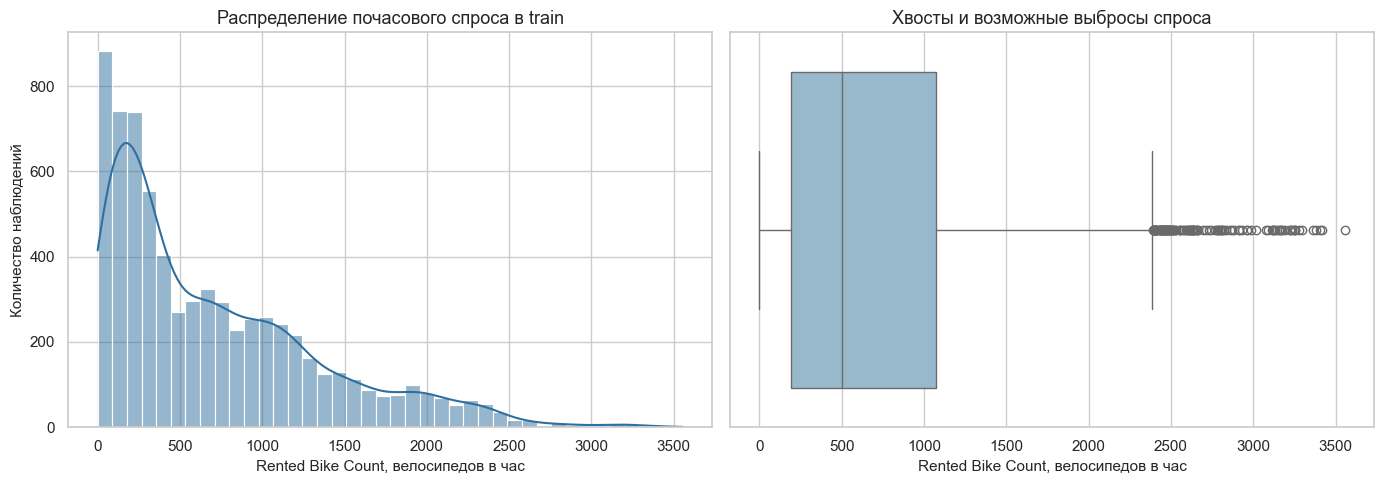

,train_target
count,"7,008.0000"
mean,705.6060
std,646.3118
min,0.0000
1%,0.0000
5%,22.0000
25%,190.7500
50%,504.5000
75%,"1,070.0000"
95%,"2,053.6000"


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train[TARGET], bins=40, kde=True, ax=axes[0], color="#2f6f9f")
axes[0].set_title("Распределение почасового спроса в train")
axes[0].set_xlabel("Rented Bike Count, велосипедов в час")
axes[0].set_ylabel("Количество наблюдений")

sns.boxplot(x=train[TARGET], ax=axes[1], color="#8fbcd4")
axes[1].set_title("Хвосты и возможные выбросы спроса")
axes[1].set_xlabel("Rented Bike Count, велосипедов в час")
plt.tight_layout()
plt.show()

target_summary = train[TARGET].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame("train_target")
display(target_summary)


**Подвывод по target:** спрос сильно асимметричен: есть много спокойных часов и длинный правый хвост с пиковыми значениями. Для бизнеса именно этот хвост критичен: если модель сгладит пики как "выбросы", прокат недооценит часы с максимальной выручкой и риском нехватки велосипедов. Поэтому пиковые наблюдения не удаляются механически, а `RMSE` оставлен основной метрикой, чтобы крупные ошибки в высоком спросе имели достаточный вес.


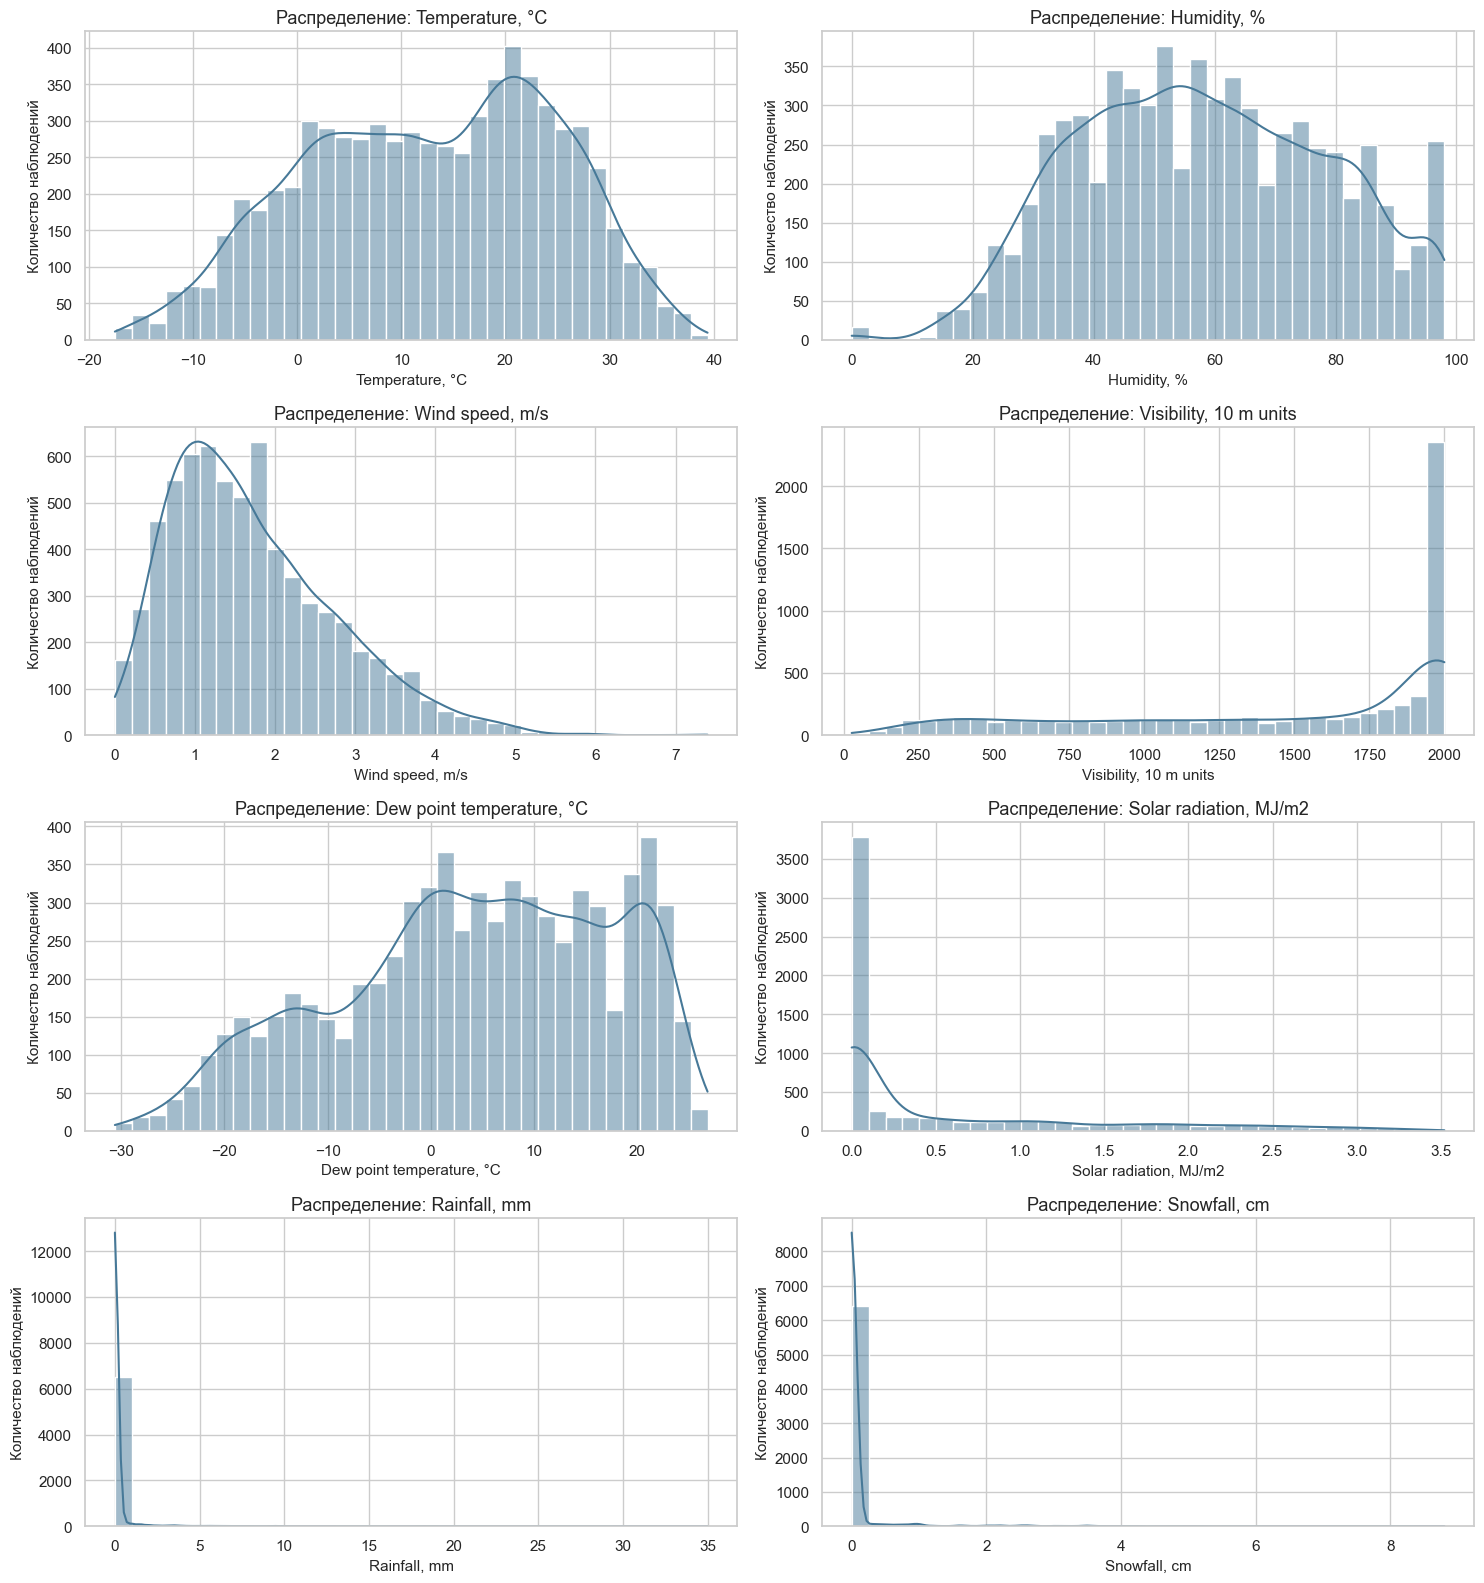

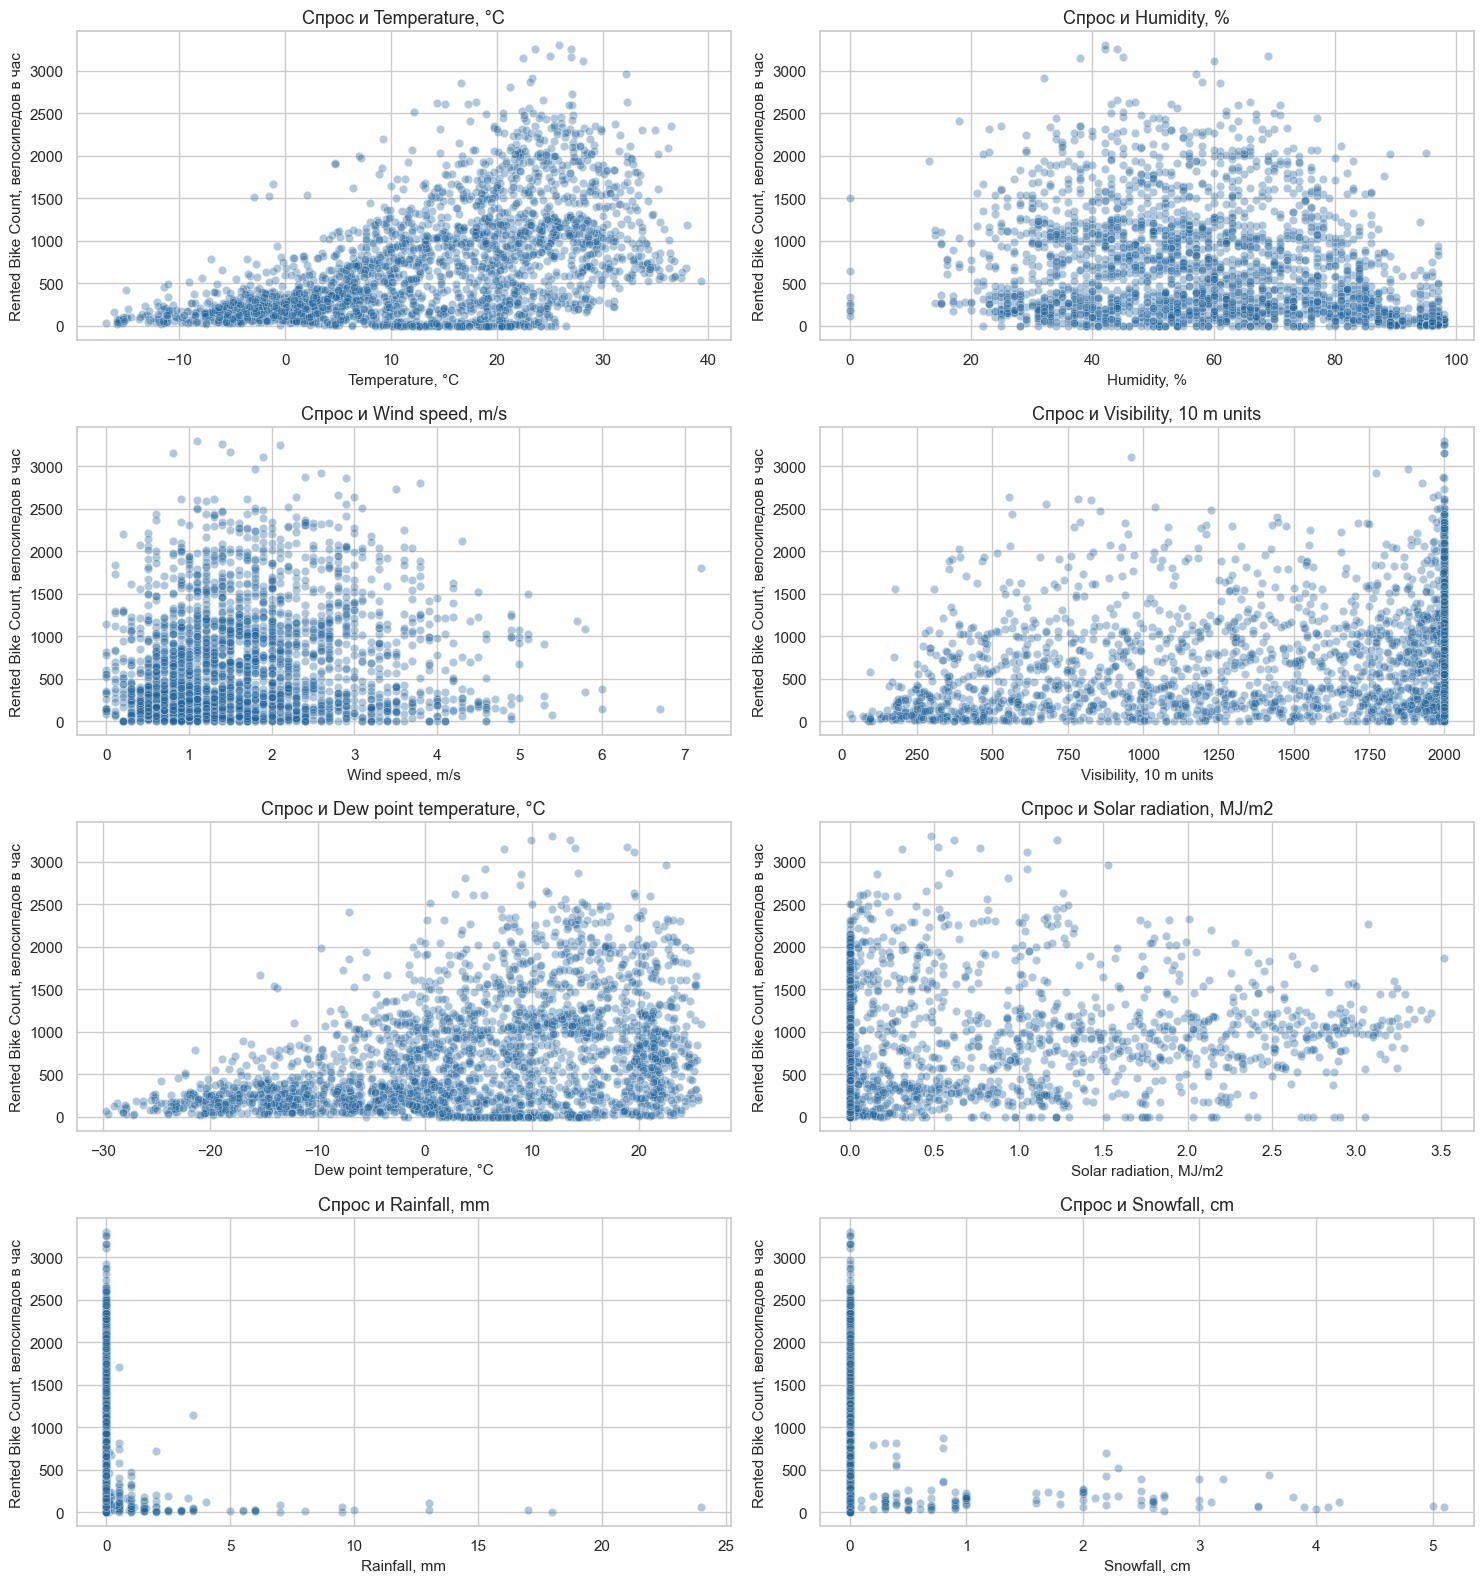

,feature,spearman_corr_with_target
0,temperature,0.5668
1,dew_point_temperature,0.3810
2,solar_radiation_mjm2,0.3785
3,rainfallmm,-0.2739
4,snowfall_cm,-0.2251
5,humidity,-0.2120
6,visibility_10m,0.1739
7,wind_speed_ms,0.1385


In [8]:
continuous_labels = {
    "temperature": "Temperature, °C",
    "humidity": "Humidity, %",
    "wind_speed_ms": "Wind speed, m/s",
    "visibility_10m": "Visibility, 10 m units",
    "dew_point_temperature": "Dew point temperature, °C",
    "solar_radiation_mjm2": "Solar radiation, MJ/m2",
    "rainfallmm": "Rainfall, mm",
    "snowfall_cm": "Snowfall, cm",
}

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()
for ax, column in zip(axes, BASE_NUMERIC_FEATURES):
    sns.histplot(train[column], bins=35, kde=True, ax=ax, color="#477998")
    ax.set_title(f"Распределение: {continuous_labels[column]}")
    ax.set_xlabel(continuous_labels[column])
    ax.set_ylabel("Количество наблюдений")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 2, figsize=(15, 16))
axes = axes.ravel()
sampled_train = train.sample(min(2500, len(train)), random_state=RANDOM_STATE)
for ax, column in zip(axes, BASE_NUMERIC_FEATURES):
    sns.scatterplot(data=sampled_train, x=column, y=TARGET, alpha=0.35, ax=ax, color="#20639b")
    ax.set_title(f"Спрос и {continuous_labels[column]}")
    ax.set_xlabel(continuous_labels[column])
    ax.set_ylabel("Rented Bike Count, велосипедов в час")
plt.tight_layout()
plt.show()

numeric_corr = (
    train[BASE_NUMERIC_FEATURES + [TARGET]]
    .corr(method="spearman", numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .reset_index()
    .rename(columns={"index": "feature", TARGET: "spearman_corr_with_target"})
)
display(numeric_corr)


**Подвывод по погодным признакам:** сильнее всего со спросом связан температурный блок: `temperature`, `dew_point_temperature`, `solar_radiation_mjm2`, а влажность имеет отрицательную связь. Для проката это не просто статистика: теплая и солнечная погода увеличивает вероятность дополнительной подачи велосипедов, а осадки и снег меняют ожидаемый режим спроса. Scatter-графики показывают нелинейность, поэтому линейного эффекта "плюс один градус = фиксированная прибавка" недостаточно; KNN/tree и weather-interaction признаки здесь методологически оправданы.


,feature,value,count,mean_demand,median_demand
0,seasons,Summer,1744,"1,046.2471",923.0000
1,seasons,Autumn,1770,820.6441,764.0000
2,seasons,Spring,1758,725.0461,578.5000
3,seasons,Winter,1736,226.4176,204.0000
4,holiday,No Holiday,6668,716.4019,524.0000
5,holiday,Holiday,340,493.8794,228.5000
6,functioning_day,Yes,6766,730.8435,546.0000
7,functioning_day,No,242,0.0000,0.0000
8,time_period_evening,True,1168,"1,193.9795","1,154.0000"
9,time_period_evening,False,5840,607.9313,422.0000


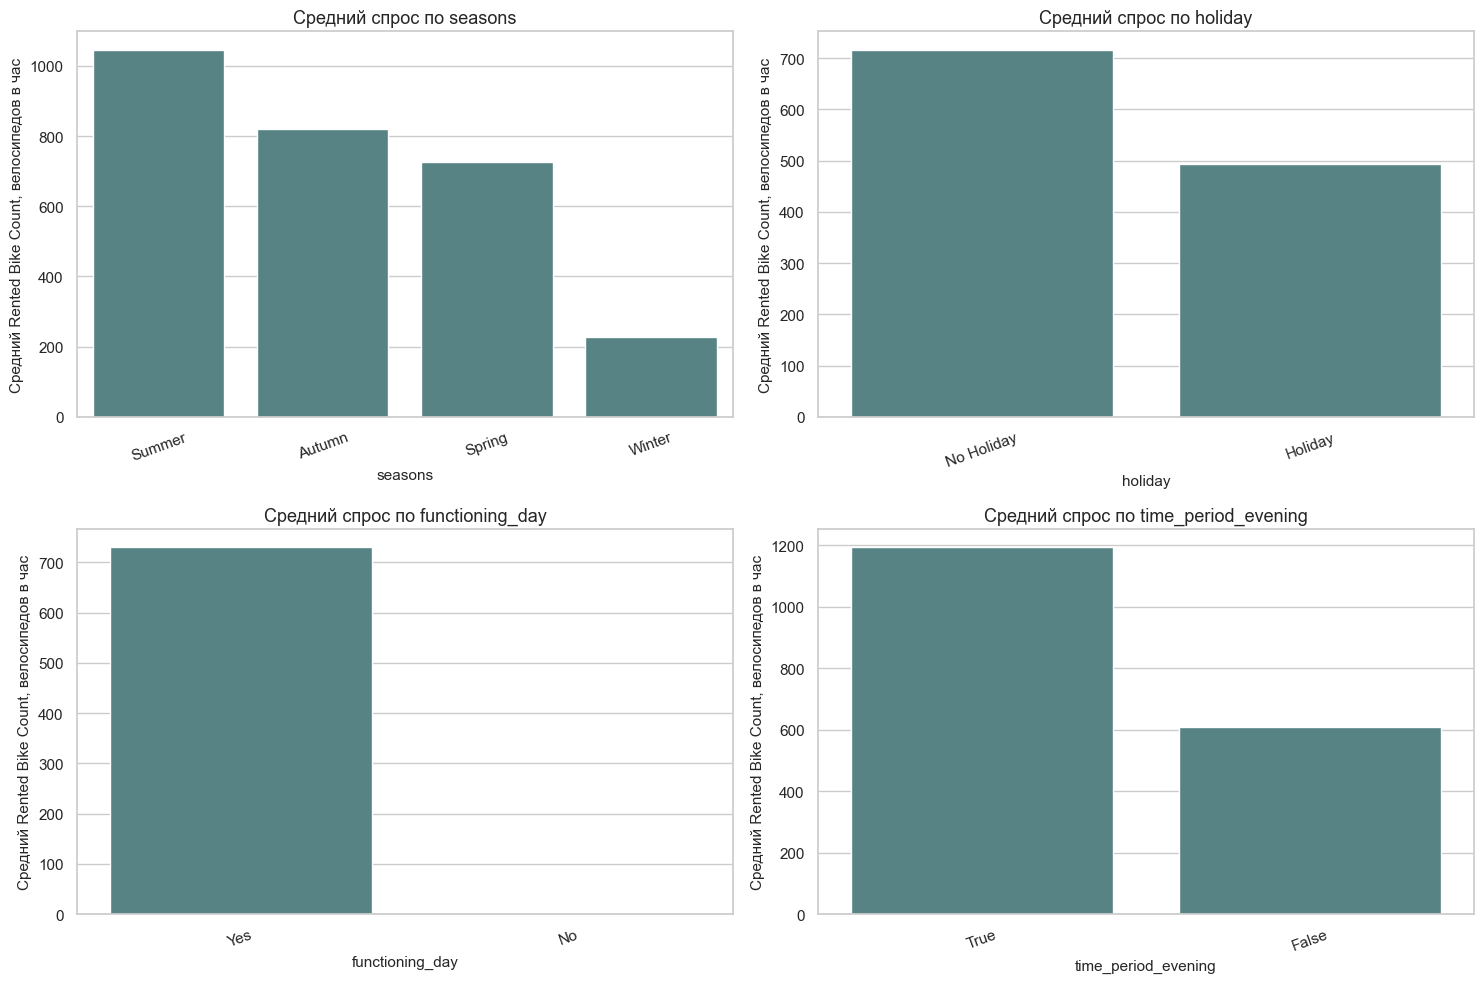

In [9]:
cat_target_tables = []
for column in CATEGORICAL_FEATURES + TIME_FEATURES:
    summary = (
        train.groupby(column, dropna=False)[TARGET]
        .agg(count="count", mean_demand="mean", median_demand="median")
        .reset_index()
        .sort_values("mean_demand", ascending=False)
    )
    summary.insert(0, "feature", column)
    cat_target_tables.append(summary.rename(columns={column: "value"}))

cat_target_summary = pd.concat(cat_target_tables, ignore_index=True)
display(cat_target_summary)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
plot_columns = ["seasons", "holiday", "functioning_day", "time_period_evening"]
for ax, column in zip(axes.ravel(), plot_columns):
    order = train.groupby(column)[TARGET].mean().sort_values(ascending=False).index
    sns.barplot(data=train, x=column, y=TARGET, order=order, estimator="mean", errorbar=None, ax=ax, color="#4f8a8b")
    ax.set_title(f"Средний спрос по {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Средний Rented Bike Count, велосипедов в час")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


**Подвывод по категориальным и временным признакам:** `seasons` и `functioning_day` дают сильный операционный сигнал. Если прокат не функционирует, нулевой спрос является режимным состоянием, а не ошибкой датчика; модель должна отличать такие часы от работающего проката с низким спросом. Time-period признаки тоже нужно сохранить: утренний, вечерний и ночной спрос отвечают разным сценариям перераспределения велосипедов и смен персонала. Скрытый `Daytime` восстанавливается как случай, когда все четыре time-period dummy равны `False`.


In [10]:
eda_decisions = pd.DataFrame(
    [
        {
            "EDA observation": "Погодные числовые признаки имеют пропуски, но доля пропусков ограничена.",
            "Modeling decision": "Не удалять строки; использовать SimpleImputer(strategy='median') внутри pipeline.",
        },
        {
            "EDA observation": "Категориальные признаки имеют небольшое число уровней.",
            "Modeling decision": "Использовать SimpleImputer(strategy='most_frequent') и OneHotEncoder(handle_unknown='ignore', drop='first').",
        },
        {
            "EDA observation": "Time_Period_Daytime скрыт как строка, где все time-period dummy равны False.",
            "Modeling decision": "Добавить `time_period_daytime` в кастомном transformer.",
        },
        {
            "EDA observation": "Температура, влажность, солнечная радиация и осадки связаны со спросом нелинейно.",
            "Modeling decision": "Обучить KNN и Decision Tree; добавить weather interaction признаки.",
        },
        {
            "EDA observation": "Baseline линейной регрессии дает отрицательные прогнозы.",
            "Modeling decision": "Проверять диапазон предсказаний финальной модели и считать negative_predictions.",
        },
        {
            "EDA observation": "Хвосты спроса выглядят как реальные пики, а не технические ошибки.",
            "Modeling decision": "Не удалять target outliers механически; оценивать RMSE и MAE вместе.",
        },
    ]
)
display(eda_decisions)


,EDA observation,Modeling decision
0,"Погодные числовые признаки имеют пропуски, но доля пропусков ограничена.",Не удалять строки; использовать SimpleImputer(strategy='median') внутри pipeline.
1,Категориальные признаки имеют небольшое число уровней.,"Использовать SimpleImputer(strategy='most_frequent') и OneHotEncoder(handle_unknown='ignore', drop='first')."
2,"Time_Period_Daytime скрыт как строка, где все time-period dummy равны False.",Добавить `time_period_daytime` в кастомном transformer.
3,"Температура, влажность, солнечная радиация и осадки связаны со спросом нелинейно.",Обучить KNN и Decision Tree; добавить weather interaction признаки.
4,Baseline линейной регрессии дает отрицательные прогнозы.,Проверять диапазон предсказаний финальной модели и считать negative_predictions.
5,"Хвосты спроса выглядят как реальные пики, а не технические ошибки.",Не удалять target outliers механически; оценивать RMSE и MAE вместе.


**Вывод этапа 4:** данные пригодны для моделирования, но требуют аккуратного pipeline. После EDA решение выглядит так: не удалять строки с пропусками, не чистить пики спроса механически, восстановить daytime, добавить погодные взаимодействия и отдельно контролировать физический диапазон прогнозов. Это напрямую связано с применением модели: прокату нужна не самая "гладкая" линия, а прогноз, который сохраняет пики, реагирует на погоду и не предлагает невозможный отрицательный спрос.


<a id="stage-5"></a>
## Этап 5. Pipeline и feature engineering

Теперь превращаю решения EDA в код. Кастомный transformer нужен не для галочки: он гарантирует стабильную схему признаков, восстанавливает скрытый `Daytime` и добавляет погодные взаимодействия без доступа к target. Transformer вынесен в `bike_demand_pipeline_components.py`, чтобы сохраненный `joblib`-pipeline открывался в чистом Python-процессе.


In [11]:
from bike_demand_pipeline_components import (
    BikeFeatureEngineer,
    CATEGORICAL_FEATURES,
    ENGINEERED_FEATURES,
    MODEL_FEATURES_AFTER_ENGINEERING,
    NUMERIC_WITH_ENGINEERED,
)


def make_preprocessor(scale_numeric: bool) -> ColumnTransformer:
    numeric_steps: List[Tuple[str, Any]] = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    numeric_pipeline = Pipeline(numeric_steps)
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, NUMERIC_WITH_ENGINEERED),
            ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )


def make_model_pipeline(model: BaseEstimator, scale_numeric: bool) -> Pipeline:
    return Pipeline(
        steps=[
            ("feature_engineering", BikeFeatureEngineer()),
            ("preprocessor", make_preprocessor(scale_numeric=scale_numeric)),
            ("model", model),
        ]
    )


schema_check = BikeFeatureEngineer().fit_transform(X_train.head(5))
display(schema_check)
assert list(schema_check.columns) == MODEL_FEATURES_AFTER_ENGINEERING
assert schema_check.shape[1] == len(MODEL_FEATURES_AFTER_ENGINEERING)


,temperature,humidity,wind_speed_ms,visibility_10m,dew_point_temperature,solar_radiation_mjm2,rainfallmm,snowfall_cm,time_period_evening,time_period_late_evening,time_period_morning,time_period_night,dew_point_gap,has_rain,has_snow,has_precipitation,comfortable_temperature,freezing_weather,hot_weather,hot_and_humid,temp_x_solar,temp_x_humidity,rain_x_wind,snow_x_freezing,time_period_daytime,seasons,holiday,functioning_day
0,20.3000,35.0000,2.4000,"2,000.0000",4.3000,0.4600,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,16.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,9.3380,710.5000,0.0000,0.0000,0.0000,Autumn,Holiday,Yes
1,25.4000,55.0000,3.2000,"2,000.0000",15.6000,0.1500,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,9.8000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,3.8100,"1,397.0000",0.0000,0.0000,0.0000,Autumn,No Holiday,Yes
2,-6.9000,39.0000,1.6000,"2,000.0000",-18.5000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,11.6000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-0.0000,-269.1000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes
3,-5.2000,37.0000,2.2000,"2,000.0000",-17.6000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,12.4000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,-0.0000,-192.4000,0.0000,0.0000,0.0000,Winter,No Holiday,Yes
4,23.4000,34.0000,2.1000,"2,000.0000",6.6000,2.8400,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,16.8000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,66.4560,795.6000,0.0000,0.0000,1.0000,Autumn,No Holiday,Yes


**Подвывод по pipeline:** кастомный transformer не обучается на target и не смотрит в test. Он только стабилизирует схему и добавляет признаки, которые прямо следуют из EDA: скрытый daytime, осадки, комфортная температура и взаимодействия погоды. Для KNN числовые признаки масштабируются, для дерева масштабирование не требуется.


<a id="stage-6"></a>
## Этап 6. Optuna и 5-fold CV

Сначала ставлю нижнюю границу через `DummyRegressor`, затем подбираю гиперпараметры для KNN и Decision Tree. Для всех новых моделей используется один и тот же CV-протокол, чтобы сравнение было честным.


In [12]:
cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
SCORING = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2",
}


def summarize_cv_scores(model_name: str, scores: Dict[str, np.ndarray], params: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    return {
        "model": model_name,
        "cv_RMSE_mean": -float(scores["test_rmse"].mean()),
        "cv_RMSE_std": float(scores["test_rmse"].std()),
        "cv_MAE_mean": -float(scores["test_mae"].mean()),
        "cv_R2_mean": float(scores["test_r2"].mean()),
        "fit_time_mean_sec": float(scores["fit_time"].mean()),
        "score_time_mean_sec": float(scores["score_time"].mean()),
        "params": params or {},
    }


def cross_validate_pipeline(model_name: str, pipeline: Pipeline, params: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=SCORING,
        cv=cv,
        n_jobs=1,
        return_train_score=False,
    )
    return summarize_cv_scores(model_name, scores, params=params)


dummy_pipeline = Pipeline(steps=[("model", DummyRegressor(strategy="mean"))])
dummy_cv_result = cross_validate_pipeline("dummy_mean", dummy_pipeline)
display(pd.DataFrame([dummy_cv_result]).drop(columns="params"))


,model,cv_RMSE_mean,cv_RMSE_std,cv_MAE_mean,cv_R2_mean,fit_time_mean_sec,score_time_mean_sec
0,dummy_mean,646.3462,6.3640,521.1947,-0.0010,0.0018,0.0021


**Подвывод по DummyRegressor:** наивная модель нужна как нижняя граница. Она не использует признаки и не требует препроцессора. Если KNN/tree не обгоняют этот уровень, значит вся инженерия признаков бессмысленна.


In [13]:
def objective_knn(trial: optuna.Trial) -> float:
    params = {
        "n_neighbors": trial.suggest_int("n_neighbors", 3, 80),
        "weights": trial.suggest_categorical("weights", ["uniform", "distance"]),
        "p": trial.suggest_int("p", 1, 2),
        "leaf_size": trial.suggest_int("leaf_size", 10, 60),
    }
    pipeline = make_model_pipeline(KNeighborsRegressor(**params), scale_numeric=True)
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=SCORING,
        cv=cv,
        n_jobs=1,
        return_train_score=False,
    )
    trial.set_user_attr("mae", -float(scores["test_mae"].mean()))
    trial.set_user_attr("r2", float(scores["test_r2"].mean()))
    trial.set_user_attr("rmse_std", float(scores["test_rmse"].std()))
    return -float(scores["test_rmse"].mean())


def objective_tree(trial: optuna.Trial) -> float:
    params = {
        "max_depth": trial.suggest_categorical("max_depth", [None, 3, 5, 7, 10, 15, 20, 30]),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 80),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 50),
        "max_features": trial.suggest_categorical("max_features", [None, "sqrt", "log2", 0.5, 0.8, 1.0]),
        "ccp_alpha": trial.suggest_float("ccp_alpha", 1e-8, 1e-2, log=True),
        "random_state": RANDOM_STATE,
    }
    pipeline = make_model_pipeline(DecisionTreeRegressor(**params), scale_numeric=False)
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        scoring=SCORING,
        cv=cv,
        n_jobs=1,
        return_train_score=False,
    )
    trial.set_user_attr("mae", -float(scores["test_mae"].mean()))
    trial.set_user_attr("r2", float(scores["test_r2"].mean()))
    trial.set_user_attr("rmse_std", float(scores["test_rmse"].std()))
    return -float(scores["test_rmse"].mean())


study_timings = {}

start = time.perf_counter()
knn_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
knn_study.optimize(objective_knn, n_trials=N_TRIALS_KNN, show_progress_bar=False)
study_timings["KNN"] = time.perf_counter() - start

start = time.perf_counter()
tree_study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
tree_study.optimize(objective_tree, n_trials=N_TRIALS_TREE, show_progress_bar=False)
study_timings["DecisionTree"] = time.perf_counter() - start

study_summary = pd.DataFrame(
    [
        {
            "model": "KNN",
            "trials": len(knn_study.trials),
            "best_RMSE": knn_study.best_value,
            "best_MAE": knn_study.best_trial.user_attrs["mae"],
            "best_R2": knn_study.best_trial.user_attrs["r2"],
            "best_RMSE_std": knn_study.best_trial.user_attrs["rmse_std"],
            "time_sec": study_timings["KNN"],
            "best_params": knn_study.best_params,
        },
        {
            "model": "DecisionTree",
            "trials": len(tree_study.trials),
            "best_RMSE": tree_study.best_value,
            "best_MAE": tree_study.best_trial.user_attrs["mae"],
            "best_R2": tree_study.best_trial.user_attrs["r2"],
            "best_RMSE_std": tree_study.best_trial.user_attrs["rmse_std"],
            "time_sec": study_timings["DecisionTree"],
            "best_params": tree_study.best_params,
        },
    ]
)
display(study_summary)


  File "D:\DS\13\ml-env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


,model,trials,best_RMSE,best_MAE,best_R2,best_RMSE_std,time_sec,best_params
0,KNN,35,319.2453,212.4093,0.7557,8.9502,30.6598,"{'n_neighbors': 9, 'weights': 'distance', 'p': 1, 'leaf_size': 10}"
1,DecisionTree,45,315.8830,210.8592,0.7608,8.6112,26.6248,"{'max_depth': 10, 'min_samples_split': 62, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 3.6698806669150484e-07}"


,model,cv_RMSE_mean,cv_RMSE_std,cv_MAE_mean,cv_R2_mean,fit_time_mean_sec,score_time_mean_sec
2,decision_tree_optuna,315.8830,8.6112,210.8592,0.7608,0.1722,0.0456
1,knn_optuna,319.2453,8.9502,212.4093,0.7557,0.0781,0.1570
0,dummy_mean,646.3462,6.3640,521.1947,-0.0010,0.0018,0.0021


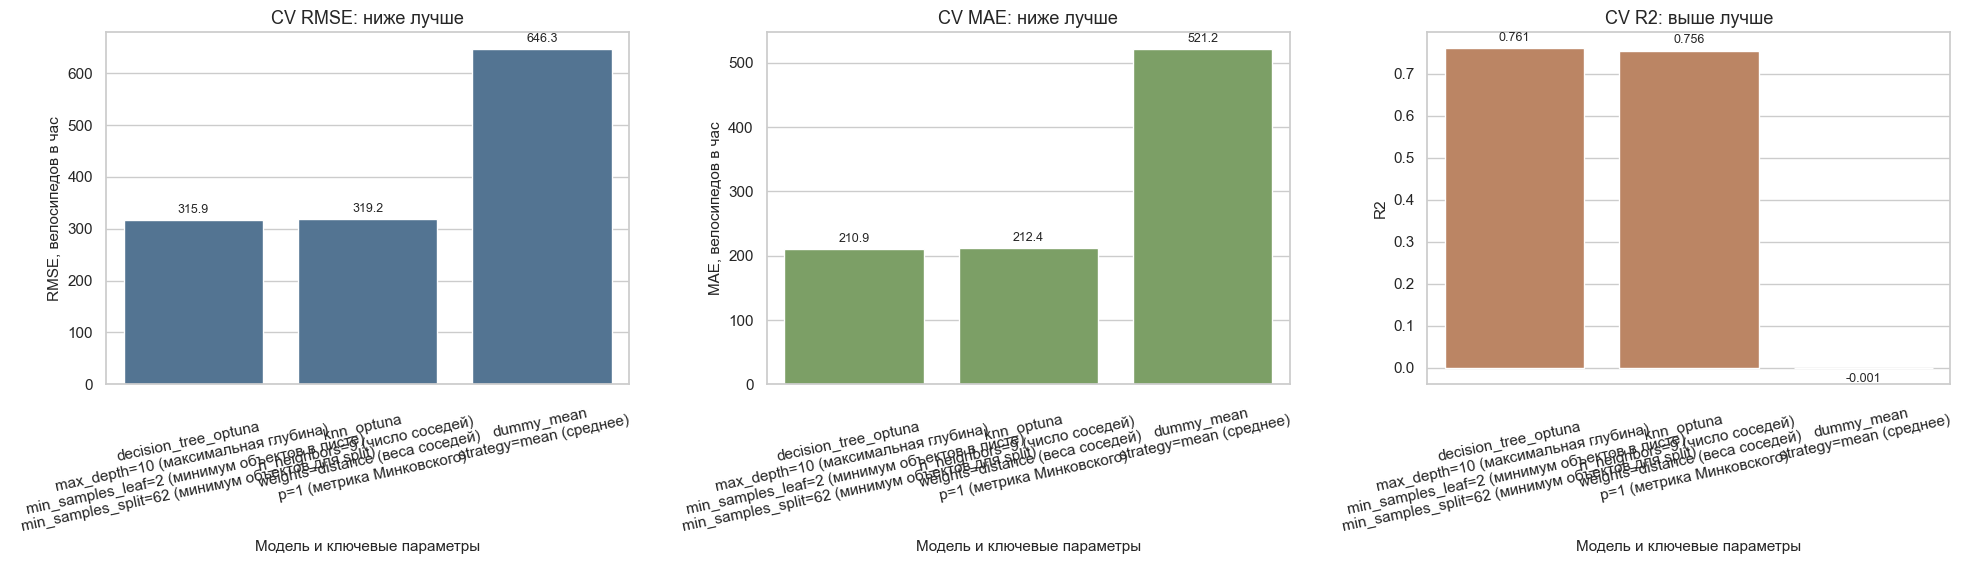

In [14]:
knn_best_pipeline = make_model_pipeline(KNeighborsRegressor(**knn_study.best_params), scale_numeric=True)
tree_best_params = dict(tree_study.best_params)
tree_best_params["random_state"] = RANDOM_STATE
tree_best_pipeline = make_model_pipeline(DecisionTreeRegressor(**tree_best_params), scale_numeric=False)

cv_results = [dummy_cv_result]
cv_results.append(cross_validate_pipeline("knn_optuna", knn_best_pipeline, params=knn_study.best_params))
cv_results.append(cross_validate_pipeline("decision_tree_optuna", tree_best_pipeline, params=tree_best_params))

cv_comparison = pd.DataFrame(cv_results).sort_values("cv_RMSE_mean")
display(cv_comparison.drop(columns="params"))

plot_df = cv_comparison.copy()
plot_df["model_label"] = [
    f"{model}\n{short_params_for_plot(model, params)}"
    for model, params in zip(plot_df["model"], plot_df["params"])
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.8))
sns.barplot(data=plot_df, x="model_label", y="cv_RMSE_mean", ax=axes[0], color="#49759c")
axes[0].set_title("CV RMSE: ниже лучше")
axes[0].set_xlabel("Модель и ключевые параметры")
axes[0].set_ylabel("RMSE, велосипедов в час")
axes[0].tick_params(axis="x", rotation=12)
add_bar_labels(axes[0], "%.1f")

sns.barplot(data=plot_df, x="model_label", y="cv_MAE_mean", ax=axes[1], color="#7aa95c")
axes[1].set_title("CV MAE: ниже лучше")
axes[1].set_xlabel("Модель и ключевые параметры")
axes[1].set_ylabel("MAE, велосипедов в час")
axes[1].tick_params(axis="x", rotation=12)
add_bar_labels(axes[1], "%.1f")

sns.barplot(data=plot_df, x="model_label", y="cv_R2_mean", ax=axes[2], color="#c98256")
axes[2].set_title("CV R2: выше лучше")
axes[2].set_xlabel("Модель и ключевые параметры")
axes[2].set_ylabel("R2")
axes[2].tick_params(axis="x", rotation=12)
add_bar_labels(axes[2], "%.3f")
plt.tight_layout()
plt.show()


In [15]:
def check_boundary_params(study: optuna.Study, model_name: str) -> pd.DataFrame:
    best = study.best_params
    if model_name == "KNN":
        ranges = {"n_neighbors": (3, 80), "leaf_size": (10, 60), "p": (1, 2)}
    else:
        ranges = {"min_samples_split": (2, 80), "min_samples_leaf": (1, 50)}
    rows = []
    for param, (low, high) in ranges.items():
        value = best.get(param)
        rows.append(
            {
                "model": model_name,
                "param": param,
                "best_value": value,
                "search_low": low,
                "search_high": high,
                "on_boundary": value in {low, high},
            }
        )
    return pd.DataFrame(rows)


boundary_check = pd.concat(
    [
        check_boundary_params(knn_study, "KNN"),
        check_boundary_params(tree_study, "DecisionTree"),
    ],
    ignore_index=True,
)
display(boundary_check)


,model,param,best_value,search_low,search_high,on_boundary
0,KNN,n_neighbors,9,3,80,False
1,KNN,leaf_size,10,10,60,True
2,KNN,p,1,1,2,True
3,DecisionTree,min_samples_split,62,2,80,False
4,DecisionTree,min_samples_leaf,2,1,50,False


**Вывод этапа 6:** новые модели сравнивались по одинаковому протоколу 5-fold CV на train. Основной выбор делается по среднему `RMSE`, но рядом проверяются `MAE`, `R2`, разброс по фолдам и границы поиска Optuna. Это защищает от ситуации, когда модель выбрана по случайному удачному фолду или по слишком узкой сетке.


<a id="stage-7"></a>
## Этап 7. Финальная проверка на test

Теперь выбираю модель по train CV, обучаю ее на всем train и один раз применяю к test. Это финальная проверка качества на данных, которые не участвовали в подборе гиперпараметров.


In [16]:
best_cv_row = cv_comparison.iloc[0]
best_model_name = best_cv_row["model"]

if best_model_name == "knn_optuna":
    final_pipeline = knn_best_pipeline
    final_params = knn_study.best_params
elif best_model_name == "decision_tree_optuna":
    final_pipeline = tree_best_pipeline
    final_params = tree_best_params
else:
    raise RuntimeError("Dummy model should not be selected as final model")

final_pipeline.fit(X_train, y_train)
final_test_predictions = final_pipeline.predict(X_test)
final_train_predictions = final_pipeline.predict(X_train)

final_results = pd.DataFrame(
    [
        evaluate_fitted_model("company_linear_baseline", baseline_pipeline, X_test, y_test, "test"),
        {
            "model": best_model_name,
            "split": "test",
            **regression_metrics(y_test, final_test_predictions),
        },
        {
            "model": best_model_name,
            "split": "train_fit_reference",
            **regression_metrics(y_train, final_train_predictions),
        },
    ]
)

baseline_test_rmse = final_results.query("model == 'company_linear_baseline' and split == 'test'")["RMSE"].iloc[0]
final_test_rmse = final_results.query("model == @best_model_name and split == 'test'")["RMSE"].iloc[0]
rmse_improvement_pct = (baseline_test_rmse - final_test_rmse) / baseline_test_rmse * 100

display(final_results)
print(f"Выбранная модель: {best_model_name}")
print(f"Улучшение RMSE относительно baseline на test: {rmse_improvement_pct:.2f}%")
print(f"Параметры финальной модели: {final_params}")


,model,split,RMSE,MAE,R2,prediction_min,prediction_max,prediction_mean,negative_predictions
0,company_linear_baseline,test,411.4545,312.5313,0.5863,-715.2865,"1,963.7774",715.3055,147
1,decision_tree_optuna,test,310.7677,207.4268,0.7640,0.0000,"2,290.0652",708.1094,0
2,decision_tree_optuna,train_fit_reference,282.0789,187.1464,0.8095,0.0000,"2,290.0652",705.6060,0


Выбранная модель: decision_tree_optuna
Улучшение RMSE относительно baseline на test: 24.47%
Параметры финальной модели: {'max_depth': 10, 'min_samples_split': 62, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 3.6698806669150484e-07, 'random_state': 42}


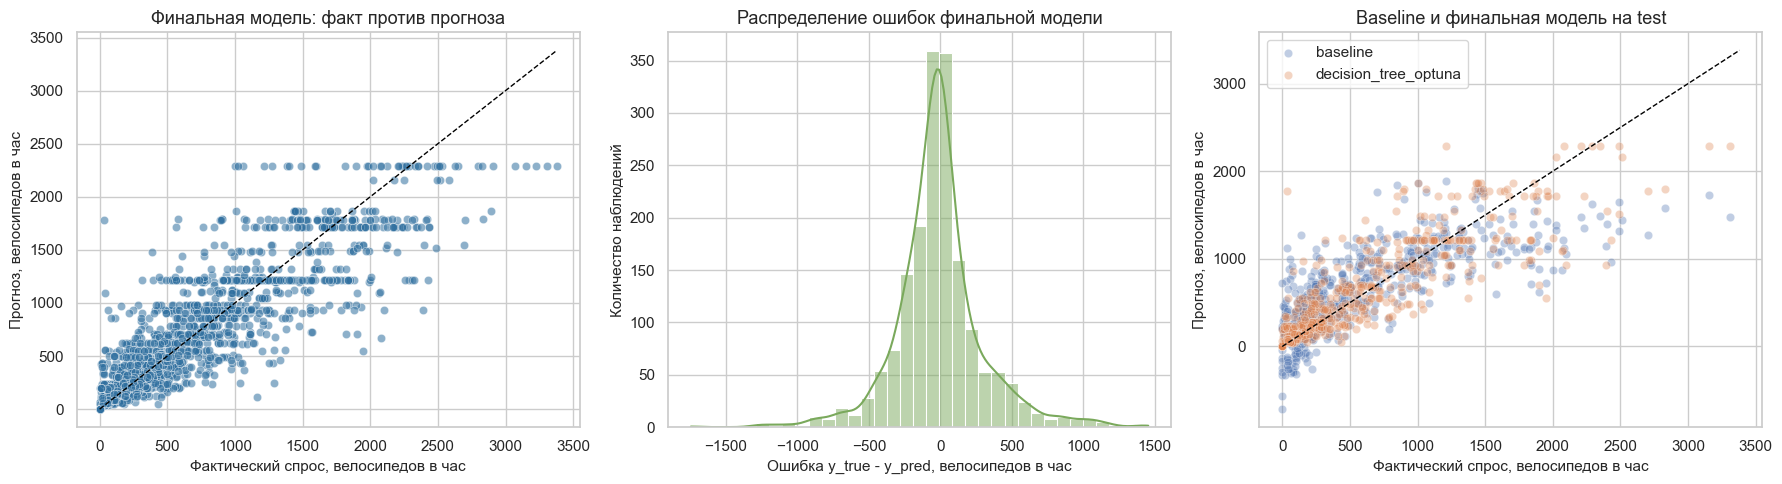

In [17]:
residuals = y_test - final_test_predictions
baseline_test_predictions = baseline_pipeline.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=y_test, y=final_test_predictions, alpha=0.55, ax=axes[0], color="#2f6f9f")
max_value = max(y_test.max(), final_test_predictions.max())
axes[0].plot([0, max_value], [0, max_value], color="black", linestyle="--", linewidth=1)
axes[0].set_title("Финальная модель: факт против прогноза")
axes[0].set_xlabel("Фактический спрос, велосипедов в час")
axes[0].set_ylabel("Прогноз, велосипедов в час")

sns.histplot(residuals, bins=35, kde=True, ax=axes[1], color="#7aa95c")
axes[1].set_title("Распределение ошибок финальной модели")
axes[1].set_xlabel("Ошибка y_true - y_pred, велосипедов в час")
axes[1].set_ylabel("Количество наблюдений")

comparison_plot = pd.DataFrame(
    {
        "actual": y_test,
        "baseline_prediction": baseline_test_predictions,
        "final_prediction": final_test_predictions,
    }
).sample(min(500, len(y_test)), random_state=RANDOM_STATE)
sns.scatterplot(data=comparison_plot, x="actual", y="baseline_prediction", alpha=0.35, label="baseline", ax=axes[2])
sns.scatterplot(data=comparison_plot, x="actual", y="final_prediction", alpha=0.35, label=best_model_name, ax=axes[2])
axes[2].plot([0, max_value], [0, max_value], color="black", linestyle="--", linewidth=1)
axes[2].set_title("Baseline и финальная модель на test")
axes[2].set_xlabel("Фактический спрос, велосипедов в час")
axes[2].set_ylabel("Прогноз, велосипедов в час")
axes[2].legend()

plt.tight_layout()
plt.show()


In [18]:
baseline_final_row = final_results.query("model == 'company_linear_baseline' and split == 'test'").iloc[0]
selected_final_row = final_results.query("model == @best_model_name and split == 'test'").iloc[0]
test_rmse_delta = baseline_final_row["RMSE"] - selected_final_row["RMSE"]
test_mae_delta = baseline_final_row["MAE"] - selected_final_row["MAE"]
test_r2_delta = selected_final_row["R2"] - baseline_final_row["R2"]

display(
    Markdown(
        f"""
        **Расчетные итоги финальной test-проверки**

        - Baseline test RMSE: `{baseline_final_row["RMSE"]:.2f}`.
        - Final test RMSE: `{selected_final_row["RMSE"]:.2f}`.
        - Улучшение RMSE: `{test_rmse_delta:.2f}` велосипеда в час (`{rmse_improvement_pct:.2f}%`).
        - Улучшение MAE: `{test_mae_delta:.2f}` велосипеда в час.
        - Прирост R2: `{test_r2_delta:.3f}`.
        - Отрицательные прогнозы baseline/final: `{int(baseline_final_row["negative_predictions"])}` / `{int(selected_final_row["negative_predictions"])}`.
        """
    )
)



        **Расчетные итоги финальной test-проверки**

        - Baseline test RMSE: `411.45`.
        - Final test RMSE: `310.77`.
        - Улучшение RMSE: `100.69` велосипеда в час (`24.47%`).
        - Улучшение MAE: `105.10` велосипеда в час.
        - Прирост R2: `0.178`.
        - Отрицательные прогнозы baseline/final: `147` / `0`.
        

**Интерпретация финальной проверки:** test используется только после выбора модели по CV, поэтому сравнение остается честным. Для BikeSouth результат стал полезнее именно в операционном смысле: типичная ошибка ниже, крупные промахи контролируются через `RMSE`, а прогнозы не уходят в невозможную отрицательную область. Модель можно рассматривать как кандидат для пилотного планирования агрегированного спроса, но не как автоматическое промышленное решение без проверки на более позднем периоде.


<a id="stage-8"></a>
## Этап 8. Интерпретация и артефакты

Интерпретация нужна, чтобы результат был полезен заказчику: модель должна не только предсказывать спрос, но и объяснять, какие факторы стоит мониторить в операционном планировании проката.


,feature_technical,feature_description_ru,importance
0,temperature,температура воздуха,0.3396
11,time_period_night,ночной период,0.1743
12,dew_point_gap,разница температуры и точки росы,0.1137
29,functioning_day_Yes,прокат работает,0.1118
8,time_period_evening,вечерний период,0.0870
9,time_period_late_evening,поздний вечер,0.0464
27,seasons_Winter,зимний сезон,0.0351
20,temp_x_solar,temp x solar,0.0229
15,has_precipitation,has precipitation,0.0143
4,dew_point_temperature,температура точки росы,0.0120


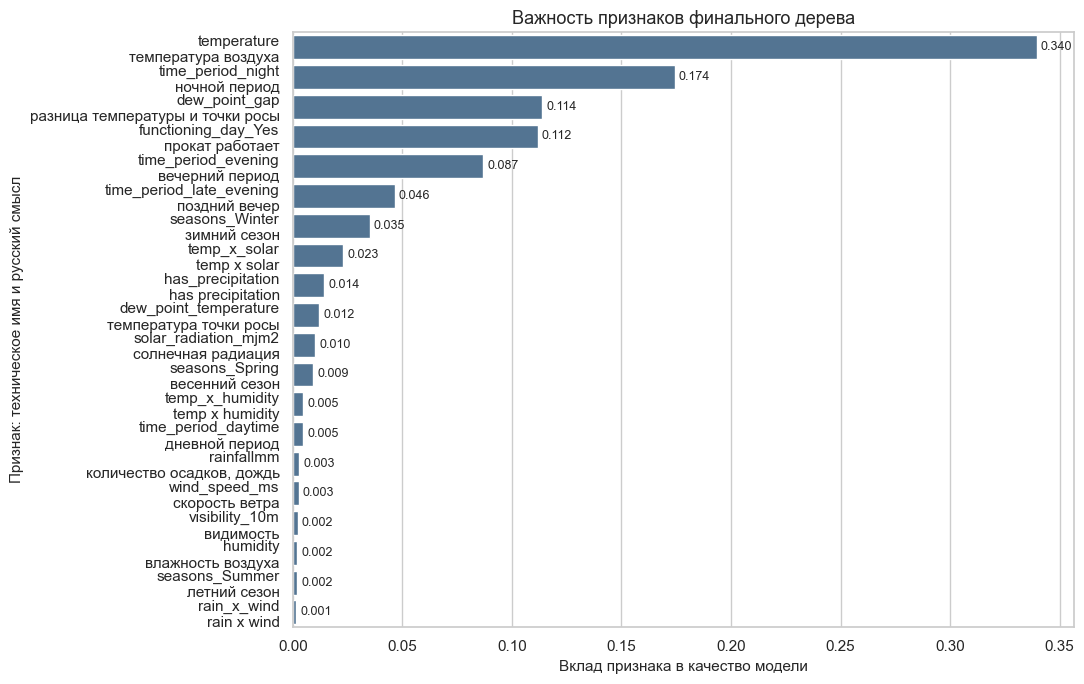

In [19]:
if best_model_name == "decision_tree_optuna":
    feature_names = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
    importances = final_pipeline.named_steps["model"].feature_importances_
    importance_table = (
        pd.DataFrame({"feature": feature_names, "importance": importances})
        .sort_values("importance", ascending=False)
        .head(20)
    )
    importance_title = "Важность признаков финального дерева"
else:
    permutation = permutation_importance(
        final_pipeline,
        X_test,
        y_test,
        scoring="neg_root_mean_squared_error",
        n_repeats=10,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    importance_table = (
        pd.DataFrame(
            {
                "feature": X_test.columns,
                "importance": permutation.importances_mean,
                "importance_std": permutation.importances_std,
            }
        )
        .sort_values("importance", ascending=False)
        .head(20)
    )
    importance_title = "Permutation importance финальной KNN-модели"

feature_labels = [
    feature_label_for_reader(feature)
    for feature in importance_table["feature"].astype(str).tolist()
]
importance_table[["feature_technical", "feature_description_ru", "feature_plot_label"]] = pd.DataFrame(
    feature_labels, index=importance_table.index
)
display(
    importance_table[
        ["feature_technical", "feature_description_ru", "importance"]
        + (["importance_std"] if "importance_std" in importance_table.columns else [])
    ]
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(data=importance_table, y="feature_plot_label", x="importance", ax=ax, color="#49759c")
ax.set_title(importance_title)
ax.set_xlabel("Вклад признака в качество модели")
ax.set_ylabel("Признак: техническое имя и русский смысл")
add_bar_labels(ax, "%.3f")
plt.tight_layout()
plt.show()


In [20]:
model_artifact_path = MODELS_DIR / "bike_demand_model.joblib"
metadata_path = MODELS_DIR / "bike_demand_model_metadata.json"
predictions_path = MODELS_DIR / "bike_demand_test_predictions.csv"
model_card_path = MODELS_DIR / "bike_demand_model_card.json"
manifest_path = MODELS_DIR / "bike_demand_artifact_manifest.json"
artifact_inventory_path = MODELS_DIR / "bike_demand_artifact_inventory.csv"

joblib.dump(final_pipeline, model_artifact_path)

predictions_frame = X_test.copy()
predictions_frame[TARGET] = y_test.values
predictions_frame["prediction"] = final_test_predictions
predictions_frame["residual"] = y_test.values - final_test_predictions
predictions_frame.to_csv(predictions_path, index=False)

def file_sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

required_component_names = [
    "BikeFeatureEngineer",
    "BASE_NUMERIC_FEATURES",
    "CATEGORICAL_FEATURES",
    "TIME_FEATURES",
    "BASE_FEATURES",
    "ENGINEERED_FEATURES",
    "NUMERIC_WITH_ENGINEERED",
    "MODEL_FEATURES_AFTER_ENGINEERING",
]
component_module = importlib.import_module(COMPONENT_MODULE_NAME)
component_symbol_check = pd.DataFrame(
    [
        {"required_name": name, "present": hasattr(component_module, name)}
        for name in required_component_names
    ]
)
component_symbols_ok = bool(component_symbol_check["present"].all())
assert component_symbols_ok, "Feature engineering component module is incomplete"

component_source_sha256 = file_sha256(COMPONENT_MODULE_PATH)

baseline_test_metrics = final_results.query(
    "model == 'company_linear_baseline' and split == 'test'"
).iloc[0].to_dict()
final_test_metrics = final_results.query(
    "model == @best_model_name and split == 'test'"
).iloc[0].to_dict()

model_card = {
    "project": "bike_demand_regression",
    "business_goal": "прогнозировать почасовой спрос на велосипеды для операционного планирования BikeSouth",
    "target": TARGET,
    "primary_metric": "RMSE",
    "secondary_metrics": ["MAE", "R2", "negative_predictions"],
    "selected_model": best_model_name,
    "selected_params": final_params,
    "test_quality": final_test_metrics,
    "baseline_test_quality": baseline_test_metrics,
    "rmse_improvement_pct_vs_baseline": float(rmse_improvement_pct),
    "training_protocol": {
        "model_selection": f"{CV_SPLITS}-fold CV только на train",
        "test_usage": "одна финальная оценка после выбора модели",
        "random_state": RANDOM_STATE,
        "optuna_trials": {"knn": N_TRIALS_KNN, "decision_tree": N_TRIALS_TREE},
    },
    "input_contract": {
        "required_columns": X_train.columns.tolist(),
        "target_column": TARGET,
        "row_grain": "одна строка = один час наблюдений велопроката",
        "not_required_at_inference": [TARGET],
    },
    "feature_engineering_contract": {
        "module": COMPONENT_MODULE_NAME,
        "source_path": str(COMPONENT_MODULE_PATH.relative_to(PROJECT_ROOT)),
        "source_sha256": component_source_sha256,
        "required_names": required_component_names,
    },
    "known_limitations": [
        "test-выборка относится к той же исходной распределенной среде, что и train; это не будущий out-of-time период",
        "перед использованием в необычную погоду, праздники или новый режим работы нужна повторная проверка",
        "часы с нулевым спросом при работающем прокате и часы неработающего проката требуют отдельного мониторинга",
    ],
    "monitoring_recommendations": [
        "RMSE, MAE, R2 и число отрицательных прогнозов на свежих размеченных партиях",
        "доля часов с нулевым спросом и строк с неработающим прокатом",
        "drift распределений температуры, влажности, дождя, снега и time-period признаков",
        "ошибка прогноза по сезонам, времени суток, праздникам и functioning_day",
    ],
}

component_manifest = {
    "component_module": COMPONENT_MODULE_NAME,
    "component_source_path": str(COMPONENT_MODULE_PATH),
    "component_source_sha256": component_source_sha256,
    "required_component_names": required_component_names,
    "component_symbols_ok": component_symbols_ok,
    "pipeline_steps": [name for name, _ in final_pipeline.steps],
    "preprocessor_transformers": [
        name for name, _, _ in final_pipeline.named_steps["preprocessor"].transformers
    ],
    "model_class": type(final_pipeline.named_steps["model"]).__name__,
    "model_params": final_params,
}

metadata = {
    "project": "bike_demand_regression",
    "random_state": RANDOM_STATE,
    "cv_splits": CV_SPLITS,
    "selected_model": best_model_name,
    "selected_params": final_params,
    "baseline_test_metrics": baseline_test_metrics,
    "final_test_metrics": final_test_metrics,
    "rmse_improvement_pct_vs_baseline": rmse_improvement_pct,
    "train_shape": train.shape,
    "test_shape": test.shape,
    "input_columns": X_train.columns.tolist(),
    "engineered_features": ENGINEERED_FEATURES,
    "component_module": COMPONENT_MODULE_NAME,
    "component_source_sha256": component_source_sha256,
    "required_component_names": required_component_names,
    "versions": versions.to_dict(orient="records"),
    "artifact_paths": {
        "model": str(model_artifact_path),
        "metadata": str(metadata_path),
        "test_predictions": str(predictions_path),
        "model_card": str(model_card_path),
        "manifest": str(manifest_path),
        "artifact_inventory": str(artifact_inventory_path),
        "component_source_module": str(COMPONENT_MODULE_PATH),
        "baseline": str(baseline_path),
    },
}

with metadata_path.open("w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2, default=str)
with model_card_path.open("w", encoding="utf-8") as file:
    json.dump(model_card, file, ensure_ascii=False, indent=2, default=str)
with manifest_path.open("w", encoding="utf-8") as file:
    json.dump(component_manifest, file, ensure_ascii=False, indent=2, default=str)

production_contract = pd.DataFrame(
    [
        {
            "contract_area": "input_schema",
            "requirement": "данные для инференса должны содержать те же исходные признаки, что и train",
            "implementation": f"{len(X_train.columns)} входных колонок перечислены в model_card['input_contract']",
        },
        {
            "contract_area": "feature_engineering_code",
            "requirement": "сохраненная модель должна поставляться вместе со всем кастомным feature engineering кодом",
            "implementation": f"{COMPONENT_MODULE_NAME}.py находится в проекте; sha256={component_source_sha256[:12]}...",
        },
        {
            "contract_area": "reproducibility",
            "requirement": "предсказания артефакта после reload должны совпадать с предсказаниями ноутбука",
            "implementation": "ниже выполняется joblib.load и сравнение через np.allclose",
        },
        {
            "contract_area": "monitoring",
            "requirement": "production-использование требует свежей разметки и мониторинга drift",
            "implementation": "model card содержит контроль метрик, сегментов и drift входных признаков",
        },
    ]
)

artifact_inventory = pd.DataFrame(
    [
        {
            "artifact": "model_pipeline",
            "path": str(model_artifact_path.relative_to(PROJECT_ROOT)),
            "exists": model_artifact_path.exists(),
            "purpose": "полный sklearn pipeline с feature engineering, preprocessing и моделью",
        },
        {
            "artifact": "metadata",
            "path": str(metadata_path.relative_to(PROJECT_ROOT)),
            "exists": metadata_path.exists(),
            "purpose": "метрики запуска, выбранные параметры, версии пакетов и пути артефактов",
        },
        {
            "artifact": "model_card",
            "path": str(model_card_path.relative_to(PROJECT_ROOT)),
            "exists": model_card_path.exists(),
            "purpose": "бизнес-цель, качество, входной контракт, ограничения и мониторинг",
        },
        {
            "artifact": "component_manifest",
            "path": str(manifest_path.relative_to(PROJECT_ROOT)),
            "exists": manifest_path.exists(),
            "purpose": "имена кастомных компонентов, checksum модуля и структура pipeline",
        },
        {
            "artifact": "test_predictions",
            "path": str(predictions_path.relative_to(PROJECT_ROOT)),
            "exists": predictions_path.exists(),
            "purpose": "построчные финальные test-предсказания и residuals",
        },
        {
            "artifact": "component_source_module",
            "path": str(COMPONENT_MODULE_PATH.relative_to(PROJECT_ROOT)),
            "exists": COMPONENT_MODULE_PATH.exists(),
            "purpose": "Python-код, необходимый для загрузки и работы сохраненного pipeline",
        },
        {
            "artifact": "baseline_pipeline",
            "path": str(baseline_path.relative_to(PROJECT_ROOT)),
            "exists": baseline_path.exists(),
            "purpose": "baseline компании, использованный для сравнения на test",
        },
    ]
)
artifact_inventory.to_csv(artifact_inventory_path, index=False)

reloaded_pipeline = joblib.load(model_artifact_path)
reloaded_predictions = reloaded_pipeline.predict(X_test)
reload_check = {
    "same_predictions_after_reload": bool(np.allclose(final_test_predictions, reloaded_predictions)),
    "max_abs_prediction_diff": float(np.max(np.abs(final_test_predictions - reloaded_predictions))),
}
artifact_check = pd.DataFrame(
    [
        {
            "check": "component module contains required names",
            "status": "OK" if component_symbols_ok else "FAIL",
            "detail": f"найдено {component_symbol_check['present'].sum()} из {len(required_component_names)} обязательных имен",
        },
        {
            "check": "all listed artifacts exist",
            "status": "OK" if bool(artifact_inventory["exists"].all()) else "FAIL",
            "detail": f"найдено {artifact_inventory['exists'].sum()} из {len(artifact_inventory)} артефактов",
        },
        {
            "check": "predictions match after joblib reload",
            "status": "OK" if reload_check["same_predictions_after_reload"] else "FAIL",
            "detail": f"max_abs_prediction_diff={reload_check['max_abs_prediction_diff']:.10f}",
        },
    ]
)

display(production_contract)
display(artifact_inventory)
display(component_symbol_check)
display(artifact_check)
display(pd.DataFrame([reload_check]))
assert reload_check["same_predictions_after_reload"], "Reloaded model predictions differ"
assert artifact_inventory["exists"].all(), "Some declared artifacts were not saved"


,contract_area,requirement,implementation
0,input_schema,"данные для инференса должны содержать те же исходные признаки, что и train",15 входных колонок перечислены в model_card['input_contract']
1,feature_engineering_code,сохраненная модель должна поставляться вместе со всем кастомным feature engineering кодом,bike_demand_pipeline_components.py находится в проекте; sha256=c68eb83dacac...
2,reproducibility,предсказания артефакта после reload должны совпадать с предсказаниями ноутбука,ниже выполняется joblib.load и сравнение через np.allclose
3,monitoring,production-использование требует свежей разметки и мониторинга drift,"model card содержит контроль метрик, сегментов и drift входных признаков"


,artifact,path,exists,purpose
0,model_pipeline,models\bike_demand_model.joblib,True,"полный sklearn pipeline с feature engineering, preprocessing и моделью"
1,metadata,models\bike_demand_model_metadata.json,True,"метрики запуска, выбранные параметры, версии пакетов и пути артефактов"
2,model_card,models\bike_demand_model_card.json,True,"бизнес-цель, качество, входной контракт, ограничения и мониторинг"
3,component_manifest,models\bike_demand_artifact_manifest.json,True,"имена кастомных компонентов, checksum модуля и структура pipeline"
4,test_predictions,models\bike_demand_test_predictions.csv,True,построчные финальные test-предсказания и residuals
5,component_source_module,bike_demand_pipeline_components.py,True,"Python-код, необходимый для загрузки и работы сохраненного pipeline"
6,baseline_pipeline,models\baseline_linear_regression_pipeline.joblib,True,"baseline компании, использованный для сравнения на test"


,required_name,present
0,BikeFeatureEngineer,True
1,BASE_NUMERIC_FEATURES,True
2,CATEGORICAL_FEATURES,True
3,TIME_FEATURES,True
4,BASE_FEATURES,True
5,ENGINEERED_FEATURES,True
6,NUMERIC_WITH_ENGINEERED,True
7,MODEL_FEATURES_AFTER_ENGINEERING,True


,check,status,detail
0,component module contains required names,OK,найдено 8 из 8 обязательных имен
1,all listed artifacts exist,OK,найдено 7 из 7 артефактов
2,predictions match after joblib reload,OK,max_abs_prediction_diff=0.0000000000


,same_predictions_after_reload,max_abs_prediction_diff
0,True,0.0000


**Вывод этапа 8:** сохранен не только алгоритм, а полный рабочий pipeline: feature engineering, preprocessors и модель. К нему привязаны metadata, model card, manifest компонентов, test predictions и inventory артефактов. Кастомный transformer вынесен в импортируемый модуль `bike_demand_pipeline_components.py`, его обязательные имена и checksum зафиксированы. После `joblib.load()` предсказания совпадают, значит артефакт можно передавать дальше без скрытой зависимости от состояния ноутбука.

Test predictions сохранены только как отчетный артефакт финальной оценки.


In [21]:
baseline_test_row = final_results.query("model == 'company_linear_baseline' and split == 'test'").iloc[0]
final_test_row = final_results.query("model == @best_model_name and split == 'test'").iloc[0]
final_cv_row = cv_comparison.query("model == @best_model_name").iloc[0]

top_feature_rows = [
    feature_label_for_reader(feature)
    for feature in importance_table["feature"].head(5).astype(str).tolist()
]
top_feature_text = "; ".join(
    f"`{technical}` - {description}"
    for technical, description, _ in top_feature_rows
)
rmse_abs_improvement = baseline_test_row["RMSE"] - final_test_row["RMSE"]
mae_abs_improvement = baseline_test_row["MAE"] - final_test_row["MAE"]
r2_abs_improvement = final_test_row["R2"] - baseline_test_row["R2"]
baseline_negative_share = baseline_test_row["negative_predictions"] / len(X_test)
final_negative_share = final_test_row["negative_predictions"] / len(X_test)

final_calculated_summary = f"""
<a id="final-conclusions"></a>

# Финальные выводы

## Расчетные итоги

- Выбранная модель: `{best_model_name}`.
- CV train: `RMSE = {final_cv_row["cv_RMSE_mean"]:.2f} ± {final_cv_row["cv_RMSE_std"]:.2f}`, `MAE = {final_cv_row["cv_MAE_mean"]:.2f}`, `R2 = {final_cv_row["cv_R2_mean"]:.3f}`.
- Baseline test: `RMSE = {baseline_test_row["RMSE"]:.2f}`, `MAE = {baseline_test_row["MAE"]:.2f}`, `R2 = {baseline_test_row["R2"]:.3f}`.
- Final test: `RMSE = {final_test_row["RMSE"]:.2f}`, `MAE = {final_test_row["MAE"]:.2f}`, `R2 = {final_test_row["R2"]:.3f}`.
- Улучшение относительно baseline: `RMSE -{rmse_abs_improvement:.2f}` велосипеда в час (`{rmse_improvement_pct:.2f}%`), `MAE -{mae_abs_improvement:.2f}`, `R2 +{r2_abs_improvement:.3f}`.
- Отрицательные прогнозы baseline: `{int(baseline_test_row["negative_predictions"])}` из `{len(X_test)}` (`{baseline_negative_share:.1%}`), минимальный прогноз `{baseline_test_row["prediction_min"]:.2f}`.
- Отрицательные прогнозы final: `{int(final_test_row["negative_predictions"])}` из `{len(X_test)}` (`{final_negative_share:.1%}`), минимальный прогноз `{final_test_row["prediction_min"]:.2f}`, средний прогноз `{final_test_row["prediction_mean"]:.2f}`.
- Ключевые признаки: {top_feature_text}.
- Параметры финальной модели: `{final_params}`.
"""

display(Markdown(final_calculated_summary))



<a id="final-conclusions"></a>

# Финальные выводы

## Расчетные итоги

- Выбранная модель: `decision_tree_optuna`.
- CV train: `RMSE = 315.88 ± 8.61`, `MAE = 210.86`, `R2 = 0.761`.
- Baseline test: `RMSE = 411.45`, `MAE = 312.53`, `R2 = 0.586`.
- Final test: `RMSE = 310.77`, `MAE = 207.43`, `R2 = 0.764`.
- Улучшение относительно baseline: `RMSE -100.69` велосипеда в час (`24.47%`), `MAE -105.10`, `R2 +0.178`.
- Отрицательные прогнозы baseline: `147` из `1752` (`8.4%`), минимальный прогноз `-715.29`.
- Отрицательные прогнозы final: `0` из `1752` (`0.0%`), минимальный прогноз `0.00`, средний прогноз `708.11`.
- Ключевые признаки: `temperature` - температура воздуха; `time_period_night` - ночной период; `dew_point_gap` - разница температуры и точки росы; `functioning_day_Yes` - прокат работает; `time_period_evening` - вечерний период.
- Параметры финальной модели: `{'max_depth': 10, 'min_samples_split': 62, 'min_samples_leaf': 2, 'max_features': None, 'ccp_alpha': 3.6698806669150484e-07, 'random_state': 42}`.


## Бизнес-интерпретация

В проекте построен проверенный прототип модели для прогноза агрегированного почасового спроса на велосипеды BikeSouth. Это решение стоит рассматривать не как академическое упражнение, а как инструмент планирования: оно помогает заранее оценивать нагрузку на прокат, готовить парк к пиковым периодам, корректировать смены и не опираться на линейный прогноз там, где спрос зависит от нелинейного сочетания погоды и режима работы.

Основная польза новой модели - снижение ошибки в тех единицах, в которых бизнес принимает решение: велосипедах в час. Дополнительно модель убирает невозможные отрицательные прогнозы, поэтому ее результат ближе к рабочему плану, а не к числу, которое нужно исправлять постобработкой перед использованием.

Важные факторы интерпретации хорошо согласуются с природой проката: спрос зависит не только от температуры, но и от времени суток, влажностного/температурного комфорта, режима работы и осадков. Поэтому нелинейная модель выглядит методологически оправданной: она лучше ловит условия, при которых спрос резко меняется, а не просто сдвигается на постоянную величину.

Ограничение применения остается существенным: модель прогнозирует общий почасовой спрос по имеющимся погодным и календарным признакам. В данных нет разреза по конкретным станциям, запасам велосипедов, городским событиям и будущей out-of-time разметке, поэтому результат нельзя честно выдавать за готовую систему распределения велосипедов по точкам.

Рекомендация: передавать модель в пилот как основу для прогноза общей нагрузки проката и сценарного планирования смен и парка. Для автоматического промышленного решения нужен следующий контур: out-of-time validation, мониторинг ошибок на свежих партиях, контроль drift по погодным признакам и отдельная проверка часов с нулевым или экстремально высоким спросом. Артефакты для такого пилота подготовлены: сохранены pipeline, metadata, model card, manifest компонентов, test predictions и inventory, а загрузка `joblib` проверена после сохранения.
